In [1]:
%%capture
!pip install --upgrade pip
!pip install equinox diffrax numpyro augmax catboost optuna
!git clone https://github.com/josephmargaryan/quantbayes.git
%cd quantbayes
!pip install -e . --no-deps

# Use a pretrained ResNet to create embeddings:
$$
X <- \phi(X) \in \mathbb{R}^d
$$

In [2]:
%%capture
!python quantbayes/stochax/save_imagenet_resnets.py

In [91]:
import equinox as eqx
import jax.random as jr

from quantbayes.stochax.vision_classification.models import ResNetClassifier
from quantbayes.stochax.vision_common import load_pretrained

model, state = eqx.nn.make_with_state(ResNetClassifier)(
    backbone="resnet18",
    num_classes=10,
    key=jr.PRNGKey(0),
)

model = load_pretrained(
    model,
    npz_path="resnet18_imagenet.npz",
    strict_fc=False,
)

# Creating Embeddings from MNIST using a pre-trained ResNet

In [92]:
import jax.numpy as jnp
import torchvision
import torchvision.transforms as transforms

# Define a transformation to convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Extract images and labels
X_torch = jnp.array(train_dataset.data.numpy())
y_torch = jnp.array(train_dataset.targets.numpy())

# Reshape X to N x C x H x W (N x 1 x H x W for grayscale)
X = jnp.expand_dims(X_torch, axis=1)

# Print shapes to confirm
print(f"Shape of X (images): {X.shape}")
print(f"Shape of y (labels): {y_torch.shape}")

Shape of X (images): (60000, 1, 28, 28)
Shape of y (labels): (60000,)


In [93]:
import jax.random as jr
import jax.numpy as jnp
from quantbayes.stochax.vision_common import extract_embeddings

key = jr.key(0)

# Repeat the single channel of MNIST images 3 times to match ResNet's expected input
X_3_channels = jnp.repeat(X, repeats=3, axis=1)

# Cast the images to float32 to match the model's expected dtype
X_3_channels = X_3_channels.astype(jnp.float32)

X = extract_embeddings(
    model,
    state,
    X = X_3_channels,
    key = key,
    family = "resnet",
    # batch_size: Optional[int] = None,
    l2_normalize = True
)
y = y_torch

In [94]:
import jax.numpy as jnp

# Calculate the L2 norm for each embedding vector (row) in X
l2_norms = jnp.linalg.norm(X, ord=2, axis=1)

# Find the maximum L2 norm
max_l2_norm = jnp.max(l2_norms)

print(f"Maximum L2 norm of the embeddings: {max_l2_norm:.4f}")

Maximum L2 norm of the embeddings: 1.0000


# Ball-DP / Ball-ReRo demonstration notebook for embedding data

This notebook demonstrates the main theorem-backed workflows in the Ball-DP library on an embedding dataset
$$
X \in \mathbb{R}^{n \times d}, \qquad y \in \{0,\dots,K-1\}.
$$

We use the label-preserving record metric
$$
d\big((x,y),(x',y')\big)
=
\begin{cases}
\|x-x'\|_2, & y=y',\\[4pt]
\infty, & y\neq y'.
\end{cases}
$$

The notebook has two main parts:

1. **Convex Gaussian output perturbation**
   - train a convex Ball-DP release,
   - run theorem-aligned attacks,
   - compute Ball-ReRo bounds.

2. **Nonconvex Poisson Ball-SGD**
   - build a theorem-backed one-hidden-layer tanh model,
   - calibrate a noise multiplier to a target privacy level,
   - train a Ball-SGD release,
   - run finite-prior transcript attacks,
   - compute both
     - the optimized **Ball-RDP $\to$ Ball-ReRo** bound, and
     - the **direct Poisson Ball-SGD Ball-ReRo** bound.

For embedding experiments, the primary theorem-aligned prior in this notebook is a **finite prior** over a same-label candidate set. We include a continuous-prior diagnostic only to illustrate the geometry.

In [95]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optax
import jax.random as jr
from sklearn.model_selection import train_test_split

from quantbayes.ball_dp import (
    ArrayDataset,
    attack_convex_ball_output_finite_prior,
    attack_nonconvex_ball_trace_finite_prior,
    ball_rero,
    fit_convex,
    get_release_step_table,
    make_finite_identification_prior,
    make_trace_metadata_from_release,
    make_uniform_ball_prior,
    plot_operator_norm_history,
    plot_release_curves,
    plot_rero_report,
    select_ball_radius,
    summarize_embedding_ball_radii,
)
from quantbayes.ball_dp.api import (
    BallOutputMapAttackConfig,
    attack_convex_ball_output,
    calibrate_ball_sgd_noise_multiplier,
    make_uniform_ball_attack_prior,
)
from quantbayes.ball_dp.attacks.ball_policy import BallTraceMapAttackConfig
from quantbayes.ball_dp.attacks.gradient_based import (
    DPSGDTraceRecorder,
    subtract_known_batch_gradients,
)
from quantbayes.ball_dp.theorem import (
    TheoremBounds,
    TheoremModelSpec,
    TrainConfig,
    certified_lz,
    fit_release,
    make_model,
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RESULTS_DIR = Path("results_ball_dp_demo")
RESULTS_DIR.mkdir(exist_ok=True)

## Data setup

This notebook assumes `X` and `y` already exist in memory.

We:
- flatten `X` to shape `(n, d)` if needed,
- re-encode labels to consecutive integers,
- split into train/test,
- inspect embedding norms.

If your embeddings are intended to be unit-normalized, normalize them *before* running this notebook.
Here we leave `X` unchanged and use the observed maximum train norm as the public theorem bound $B$.

In [96]:
# Assumes X, y already exist in memory.
X = np.asarray(X, dtype=np.float32)
if X.ndim != 2:
    X = X.reshape(len(X), -1)

y_raw = np.asarray(y)
label_values, y = np.unique(y_raw, return_inverse=True)
y = y.astype(np.int32)

seed = 0
preferred_target_index = 17

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

train_ds = ArrayDataset(X_train, y_train, name="train")
test_ds = ArrayDataset(X_test, y_test, name="test")

num_classes = int(len(np.unique(y_train)))
feature_dim = int(X_train.shape[1])

train_norms = np.linalg.norm(X_train, axis=1)
test_norms = np.linalg.norm(X_test, axis=1)
B_public = float(np.max(train_norms))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("num_classes:", num_classes)
print("feature_dim:", feature_dim)
print("label mapping:", {int(i): label_values[i] for i in range(len(label_values))})
print("train norm stats:")
print("  min =", float(np.min(train_norms)))
print("  mean =", float(np.mean(train_norms)))
print("  max =", float(np.max(train_norms)))
print("test norm stats:")
print("  min =", float(np.min(test_norms)))
print("  mean =", float(np.mean(test_norms)))
print("  max =", float(np.max(test_norms)))
print("public theorem bound B =", B_public)

X_train shape: (48000, 512)
X_test shape: (12000, 512)
num_classes: 10
feature_dim: 512
label mapping: {0: np.int32(0), 1: np.int32(1), 2: np.int32(2), 3: np.int32(3), 4: np.int32(4), 5: np.int32(5), 6: np.int32(6), 7: np.int32(7), 8: np.int32(8), 9: np.int32(9)}
train norm stats:
  min = 0.9999998211860657
  mean = 1.0
  max = 1.0000001192092896
test norm stats:
  min = 0.9999998211860657
  mean = 1.0
  max = 1.0000001192092896
public theorem bound B = 1.0000001192092896


## Choose the Ball radius $r$

Under the label-preserving metric, only within-label Euclidean distances matter.

We compute empirical within-label distance summaries and choose a default policy radius using
$$
r = \max_c \; q_{0.80}^{(c)},
$$
the worst-class 80th percentile of within-label pairwise distances.

This is only a default. You can override it manually if your paper wants a specific policy radius.

In [97]:
radius_report = summarize_embedding_ball_radii(
    X_train,
    y_train,
    quantiles=(0.5, 0.8, 0.9, 0.95, 0.99, 1.0),
    max_exact_pairs=250_000,
    max_sampled_pairs=100_000,
    seed=seed,
)

print("Candidate radii:")
for k, v in radius_report["candidate_radii"].items():
    print(f"  {k:>24s} : {float(v):.6f}")

radius = select_ball_radius(
    radius_report,
    strategy="max_labelwise_quantile",
    quantile=0.80,
)

# Optional manual override:
# radius = 0.10

print("\nChosen Ball radius r =", float(radius))

Candidate radii:
               pooled_q0.5 : 0.424300
        max_labelwise_q0.5 : 0.457425
       mean_labelwise_q0.5 : 0.424638
               pooled_q0.8 : 0.498134
        max_labelwise_q0.8 : 0.543714
       mean_labelwise_q0.8 : 0.498100
               pooled_q0.9 : 0.539474
        max_labelwise_q0.9 : 0.595284
       mean_labelwise_q0.9 : 0.535930
              pooled_q0.95 : 0.575190
       max_labelwise_q0.95 : 0.631239
      mean_labelwise_q0.95 : 0.566131
              pooled_q0.99 : 0.643862
       max_labelwise_q0.99 : 0.689083
      mean_labelwise_q0.99 : 0.618288
                 pooled_q1 : 0.799109
          max_labelwise_q1 : 0.799109
         mean_labelwise_q1 : 0.734525
       global_max_observed : 0.799109

Chosen Ball radius r = 0.5437141060829163


## Finite prior vs. continuous prior

For embedding experiments, the main theorem-aligned prior in this notebook is a **finite prior** on a candidate set.

Why:

- For a continuous uniform prior on an $L_2$ ball in dimension $d$,
  $$
  \kappa(\eta)=\left(\frac{\eta}{r}\right)^d \qquad (\eta<r).
  $$
  In high dimension, this changes extremely fast with $\eta/r$, so the bound is often either:
  - essentially $0$, or
  - vacuous near $\eta=r$.

- For a uniform finite prior on $m$ candidates in the exact-identification setting,
  $$
  \kappa=\frac{1}{m},
  $$
  which is stable and interpretable.

So the notebook uses:

- **finite prior exact identification** as the primary reported experiment;
- **oracle-centered continuous prior** only as an optional geometry diagnostic.

We also explicitly check whether a class-mean Ball prior would even contain the target.

In [98]:
def choose_target_index(y_train, y_pool, *, preferred=17, min_pool_per_label=8):
    preferred = int(preferred)
    if 0 <= preferred < len(y_train):
        if np.sum(y_pool == y_train[preferred]) >= int(min_pool_per_label):
            return preferred
    for idx in range(len(y_train)):
        if np.sum(y_pool == y_train[idx]) >= int(min_pool_per_label):
            return idx
    raise ValueError(
        "Could not find a training target whose label has enough held-out same-label candidates."
    )


def build_same_label_finite_support(
    x_target,
    target_label,
    X_pool,
    y_pool,
    *,
    max_candidates=16,
):
    """Build a same-label finite support from held-out data and append the true target.

    This is the primary exact-identification prior used in the notebook.
    It guarantees that the true target is in the candidate support.
    """
    x_target = np.asarray(x_target, dtype=np.float32).reshape(-1)
    mask = (np.asarray(y_pool) == int(target_label))
    pool = np.asarray(X_pool[mask], dtype=np.float32).reshape(np.sum(mask), -1)

    if len(pool) == 0:
        raise ValueError("No same-label held-out candidates available.")

    dists = np.linalg.norm(pool - x_target[None, :], axis=1)
    order = np.argsort(dists)

    chosen = []
    for j in order:
        cand = np.asarray(pool[j], dtype=np.float32)
        if np.allclose(cand, x_target, atol=1e-8, rtol=0.0):
            continue
        chosen.append(cand)
        if len(chosen) >= int(max_candidates) - 1:
            break

    chosen.append(x_target)

    uniq = []
    for z in chosen:
        if not any(np.allclose(z, u, atol=1e-8, rtol=0.0) for u in uniq):
            uniq.append(np.asarray(z, dtype=np.float32))

    X_candidates = np.stack(uniq, axis=0)
    y_candidates = np.full((len(X_candidates),), int(target_label), dtype=np.int32)
    return X_candidates, y_candidates


def build_same_label_support_from_center(
    center,
    target_label,
    X_pool,
    y_pool,
    *,
    radius,
    max_candidates=32,
):
    """Side-information-driven helper for future realistic runs.

    This does NOT guarantee the true target is in support. Use it when the center
    comes from attacker side information. Then either:
      - only evaluate targets satisfying ||z - center|| <= radius, or
      - treat prior misspecification as a separate experiment.
    """
    center = np.asarray(center, dtype=np.float32).reshape(-1)
    mask = (np.asarray(y_pool) == int(target_label))
    pool = np.asarray(X_pool[mask], dtype=np.float32).reshape(np.sum(mask), -1)
    if len(pool) == 0:
        raise ValueError("No same-label pool points available.")
    dists = np.linalg.norm(pool - center[None, :], axis=1)
    keep = np.where(dists <= float(radius))[0]
    if len(keep) == 0:
        raise ValueError("No same-label candidates lie inside the requested Ball.")
    order = keep[np.argsort(dists[keep])]
    order = order[: int(max_candidates)]
    X_candidates = np.asarray(pool[order], dtype=np.float32)
    y_candidates = np.full((len(X_candidates),), int(target_label), dtype=np.int32)
    return X_candidates, y_candidates


target_index = choose_target_index(
    y_train,
    y_test,
    preferred=preferred_target_index,
    min_pool_per_label=8,
)
target_label = int(y_train[target_index])
x_target = np.asarray(X_train[target_index], dtype=np.float32).reshape(-1)
true_record = train_ds.record(target_index)

X_candidates, y_candidates = build_same_label_finite_support(
    x_target,
    target_label,
    X_test,
    y_test,
    max_candidates=16,
)
finite_prior = make_finite_identification_prior(X_candidates, weights=None)
m_candidates = int(len(X_candidates))

u_classmean = np.asarray(
    X_train[y_train == target_label].mean(axis=0),
    dtype=np.float32,
).reshape(-1)
oracle_continuous_prior = make_uniform_ball_prior(center=x_target, radius=radius)
oracle_attack_prior = make_uniform_ball_attack_prior(center=x_target, radius=radius)

attack_eta_grid = tuple(float(radius * q) for q in (0.25, 0.50, 0.75, 1.00))
finite_eta_grid = (0.5,)  # any eta < 1 is equivalent in the exact-ID theorem
continuous_ratio_grid = (0.90, 0.95, 0.97, 0.98, 0.99, 0.995)
continuous_eta_grid = tuple(float(radius * q) for q in continuous_ratio_grid)

print("target_index:", target_index)
print("target_label:", target_label)
print("finite prior size m:", m_candidates)
print("exact-ID oblivious baseline 1/m:", 1.0 / m_candidates)
print("distance(target, class mean center):", float(np.linalg.norm(x_target - u_classmean)))
print("target inside class-mean Ball?", bool(np.linalg.norm(x_target - u_classmean) <= radius))
print("target inside oracle-centered Ball?", bool(np.linalg.norm(x_target - x_target) <= radius))

target_index: 17
target_label: 4
finite prior size m: 16
exact-ID oblivious baseline 1/m: 0.0625
distance(target, class mean center): 0.28523334860801697
target inside class-mean Ball? True
target inside oracle-centered Ball? True


# Part I — Convex Gaussian output perturbation

We use the convex Gaussian release
$$
\tilde \theta = \hat\theta(D) + \xi, \qquad \xi \sim \mathcal N(0,\sigma^2 I).
$$

For strongly convex ERM,
$$
\|\hat\theta(D)-\hat\theta(D')\|_2 \le \Delta_2(r),
$$
and the direct Gaussian Ball-ReRo theorem gives
$$
\gamma_{\mathrm{dir}}(\eta)
=
\Phi\!\left(
\Phi^{-1}(\kappa(\eta)) + \frac{\Delta_2(r)}{\sigma}
\right).
$$

For the finite exact-identification prior with uniform weights on \(m\) candidates,
$$
\kappa = \frac{1}{m},
$$
so the exact-identification upper bound is a single scalar.

In [99]:
release_convex = fit_convex(
    X_train,
    y_train,
    X_eval=X_test,
    y_eval=y_test,
    model_family="ridge-prototype",
    privacy="ball_dp",
    radius=radius,
    lam=1e-2,
    epsilon=3.0,
    delta=1e-6,
    embedding_bound=B_public,
    num_classes=num_classes,
    solver="lbfgs_fullbatch",
    max_iter=200,
    early_stop=True,
    stop_rule="grad_only",
    min_iter=20,
    seed=seed,
)

print("release kind:", release_convex.release_kind)
print("utility:", release_convex.utility_metrics)
print("ball sensitivity Δ_ball:", release_convex.sensitivity.delta_ball)
print("standard sensitivity Δ_std:", release_convex.sensitivity.delta_std)
print("Gaussian sigma:", release_convex.privacy.ball.sigma)

if release_convex.privacy.ball.dp_certificates:
    cert = release_convex.privacy.ball.dp_certificates[0]
    print("Ball-DP certificate:")
    print("  epsilon =", cert.epsilon)
    print("  delta   =", cert.delta)

release kind: convex_ball_erm_dp
utility: {'accuracy': 0.7825}
ball sensitivity Δ_ball: 0.0022560751289747564
standard sensitivity Δ_std: 0.008298756176010702
Gaussian sigma: 0.0034830673472261544
Ball-DP certificate:
  epsilon = 2.999999999998181
  delta   = 1e-06


## Primary convex attack: finite-prior exact Bayes classifier

This is the theorem-aligned attack for embeddings:
we score every candidate in the finite support exactly.

Because the prior is finite and the support contains the true target, the main metric is

- `exact_identification_success`,
- plus rank-style diagnostics (`prior_rank`, `prior_hit@k`),
- and secondary embedding metrics (`feature_l2`, `feature_cosine`, etc.).

In [100]:
attack_convex_finite, d_minus_convex, target_convex = attack_convex_ball_output_finite_prior(
    release_convex,
    X_train,
    y_train,
    target_index=target_index,
    X_candidates=X_candidates,
    y_candidates=y_candidates,
    prior_weights=None,
    known_label=target_label,
    eta_grid=attack_eta_grid,
)

print("status:", attack_convex_finite.status)
print("prior size:", attack_convex_finite.diagnostics.get("prior_size"))
print("true record in prior:", attack_convex_finite.diagnostics.get("true_record_in_prior"))

important_attack_keys = [
    "exact_identification_success",
    "prior_rank",
    "prior_hit@1",
    "prior_hit@5",
    "oblivious_kappa",
    "feature_l2",
    "feature_cosine",
    "feature_angle_deg",
]
for k in important_attack_keys:
    if k in attack_convex_finite.metrics:
        print(f"{k:>26s} :", attack_convex_finite.metrics[k])

status: ok_known_label
prior size: 16
true record in prior: True
exact_identification_success : 0.0
                prior_rank : 10.0
               prior_hit@1 : 0.0
               prior_hit@5 : 0.0
           oblivious_kappa : 0.0625
                feature_l2 : 0.2583463191986084
            feature_cosine : 0.9666285514831543
         feature_angle_deg : 14.843638535669866


## Optional convex Ball-Attack I: continuous Ball-constrained MAP

This is the continuous Ball MAP attack from the Gaussian-output section.

Important notes:

- It is **not** the primary embedding experiment here.
- We center the Ball at the **true target** only as a diagnostic, so the feasible set definitely contains the truth.
- This isolates the privacy mechanism from prior misspecification.

Runtime note:

- this continuous MAP attack is slower than the finite-prior exact Bayes attack;
- for general convex heads it can be much slower because objective evaluations may solve a candidate ERM.
- For ridge prototypes it is much cheaper, so it is reasonable as a diagnostic.

In [13]:
attack_convex_cont, _, _ = attack_convex_ball_output(
    release_convex,
    X_train,
    y_train,
    target_index=target_index,
    prior=oracle_attack_prior,
    cfg=BallOutputMapAttackConfig(
        optimizer="adam",
        num_steps=100,
        learning_rate=5e-2,
        num_restarts=3,
        seed=seed,
    ),
    known_label=target_label,
    eta_grid=attack_eta_grid,
)

print("status:", attack_convex_cont.status)
for k in [
    "feature_l2",
    "feature_cosine",
    "feature_angle_deg",
    f"success@{attack_eta_grid[0]:g}",
    f"success@{attack_eta_grid[1]:g}",
    f"success@{attack_eta_grid[2]:g}",
    f"success@{attack_eta_grid[3]:g}",
    "objective_gap_to_truth",
]:
    if k in attack_convex_cont.metrics:
        print(f"{k:>26s} :", attack_convex_cont.metrics[k])

status: ok_known_label
                feature_l2 : 0.5437141060829163
            feature_cosine : 0.885275661945343
         feature_angle_deg : 27.714536541673553
          success@0.135929 : 0.0
          success@0.271857 : 0.0
          success@0.407786 : 0.0
          success@0.543714 : 1.0
    objective_gap_to_truth : -0.7666015625


## Convex Ball-ReRo bounds on the finite prior

For the finite exact-identification prior, all $\eta<1$ are equivalent.

So we use a single value:
```python
eta_grid = (0.5,)
```
We compute:

the generic theorem route `(mode="dp")`, and
the direct Gaussian theorem `(mode="gaussian_direct")`.

The direct Gaussian theorem is usually the sharper one here.

In [14]:
report_convex_dp = ball_rero(
    release_convex,
    prior=finite_prior,
    eta_grid=finite_eta_grid,
    mode="dp",
)

report_convex_direct = ball_rero(
    release_convex,
    prior=finite_prior,
    eta_grid=finite_eta_grid,
    mode="gaussian_direct",
)

p_convex_dp = report_convex_dp.points[0]
p_convex_dir = report_convex_direct.points[0]

print("finite-prior exact-ID setting")
print("  m =", m_candidates)
print("  kappa = 1/m =", p_convex_dir.kappa)
print("  attack exact-id success =", attack_convex_finite.metrics.get("exact_identification_success"))
print("  generic DP Ball-ReRo upper bound (ball) =", p_convex_dp.gamma_ball)
print("  direct Gaussian Ball-ReRo upper bound (ball) =", p_convex_dir.gamma_ball)
print("  direct Gaussian comparator (standard) =", p_convex_dir.gamma_standard)

finite-prior exact-ID setting
  m = 16
  kappa = 1/m = 0.0625
  attack exact-id success = 0.0
  generic DP Ball-ReRo upper bound (ball) = 1.0
  direct Gaussian Ball-ReRo upper bound (ball) = 0.18770262195637893
  direct Gaussian comparator (standard) = 0.8019144885876335


## Optional geometry diagnostic for the continuous prior

For a continuous uniform Ball prior in dimension \(d\),
$$
\kappa(\eta)=\left(\frac{\eta}{r}\right)^d \qquad (\eta<r).
$$

The log-slope is
$$
\frac{d}{d\eta}\log \kappa(\eta)=\frac{d}{\eta},
$$
so in high dimension the transition is very sharp near $\eta/r = 1$.

That is why continuous-prior Ball-ReRo curves often look either:
- essentially $0$, or
- vacuous near $r$.

We illustrate that below with an oracle-centered continuous prior.

continuous-prior kappa values
eta/r = 0.9 kappa = 3.733918487410248e-24
eta/r = 0.95 kappa = 3.930844897840082e-12
eta/r = 0.97 kappa = 1.6870499616222877e-07
eta/r = 0.98 kappa = 3.219220721790006e-05
eta/r = 0.99 kappa = 0.005823976768663671
eta/r = 0.995 kappa = 0.07680992513462541


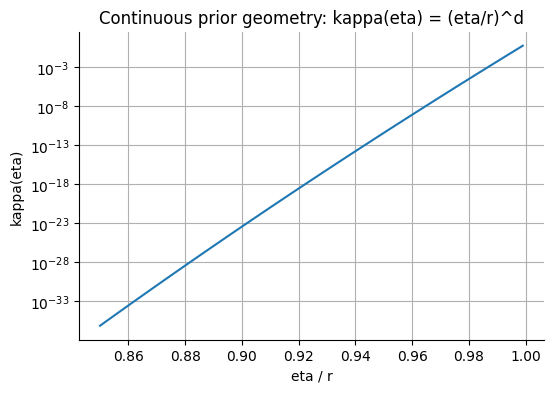

eta = 0.48934269547462467 eta/r = 0.9 kappa = 3.733918487410248e-24 gamma_ball = 0.0 gamma_standard = 7.494005416219807e-15
eta = 0.5165284007787704 eta/r = 0.9499999999999998 kappa = 3.930844897840082e-12 gamma_ball = 2.9455038408343626e-10 gamma_standard = 4.127795209141194e-06
eta = 0.5274026829004288 eta/r = 0.9700000000000001 kappa = 1.6870499616222877e-07 gamma_ball = 4.2235405370294465e-06 gamma_standard = 0.00327740436306323
eta = 0.532839823961258 eta/r = 0.98 kappa = 3.219220721790006e-05 gamma_ball = 0.00040638231189044083 gamma_standard = 0.05331391563422638
eta = 0.5382769650220871 eta/r = 0.99 kappa = 0.005823976768663671 gamma_ball = 0.03040272152208845 gamma_standard = 0.44431652140305306
eta = 0.5409955355525017 eta/r = 0.995 kappa = 0.07680992513462541 gamma_ball = 0.21795013721057516 gamma_standard = 0.8303978371372964


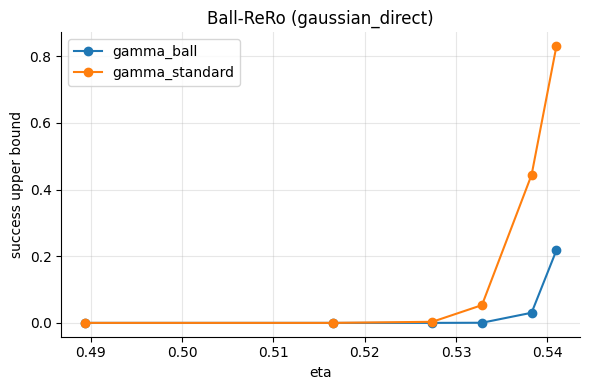

In [15]:
print("continuous-prior kappa values")
for eta in continuous_eta_grid:
    print(
        "eta/r =",
        round(float(eta / radius), 6),
        "kappa =",
        oracle_continuous_prior.kappa(float(eta)),
    )

ratio_dense = np.linspace(0.85, 0.999, 80)
kappa_dense = np.array([float(q ** feature_dim) for q in ratio_dense], dtype=np.float64)

plt.figure(figsize=(6, 4))
plt.semilogy(ratio_dense, kappa_dense)
plt.xlabel("eta / r")
plt.ylabel("kappa(eta)")
plt.title("Continuous prior geometry: kappa(eta) = (eta/r)^d")
plt.show()

report_convex_cont_direct = ball_rero(
    release_convex,
    prior=oracle_continuous_prior,
    eta_grid=continuous_eta_grid,
    mode="gaussian_direct",
)

for point in report_convex_cont_direct.points:
    print(
        "eta =", point.eta,
        "eta/r =", point.eta / radius,
        "kappa =", point.kappa,
        "gamma_ball =", point.gamma_ball,
        "gamma_standard =", point.gamma_standard,
    )

plot_rero_report(report_convex_cont_direct)

## Primary convex result for embeddings: finite-prior exact identification

For embedding experiments, the more informative theorem-aligned result is the finite-prior exact-identification setting.

Here the prior is uniform on \(m\) feasible same-label candidates, so
$$
\kappa=\frac{1}{m}.
$$

Under the exact-identification loss $\rho_{0/1}$, all $\eta<1$ are equivalent, so the theorem gives a **single scalar upper bound** rather than an $\eta$-curve.

That is why we summarize this setting with:
- the oblivious baseline $1/m$,
- empirical exact-identification success,
- the generic DP Ball-ReRo bound,
- the direct Gaussian Ball-ReRo bound.

In [82]:
# Finite-prior convex summary: this is the primary embedding result.

p_convex_dp = report_convex_dp.points[0]
p_convex_dir = report_convex_direct.points[0]

print("FINITE-PRIOR EXACT-ID (primary convex embedding result)")
print("m =", m_candidates)
print("oblivious baseline 1/m =", 1.0 / m_candidates)
print("empirical exact-ID success =", attack_convex_finite.metrics.get("exact_identification_success"))
print("generic DP Ball-ReRo bound (ball) =", p_convex_dp.gamma_ball)
print("generic DP Ball-ReRo comparator (standard) =", p_convex_dp.gamma_standard)
print("direct Gaussian Ball-ReRo bound (ball) =", p_convex_dir.gamma_ball)
print("direct Gaussian Ball-ReRo comparator (standard) =", p_convex_dir.gamma_standard)

FINITE-PRIOR EXACT-ID (primary convex embedding result)
m = 16
oblivious baseline 1/m = 0.0625
empirical exact-ID success = 0.0
generic DP Ball-ReRo bound (ball) = 1.0
generic DP Ball-ReRo comparator (standard) = 1.0
direct Gaussian Ball-ReRo bound (ball) = 0.18770262195637893
direct Gaussian Ball-ReRo comparator (standard) = 0.8019144885876335


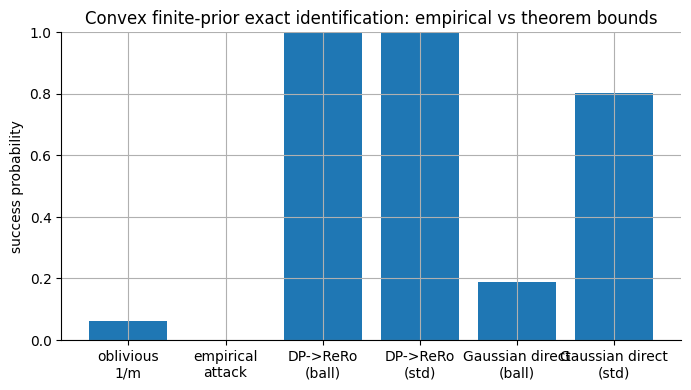

In [83]:
import matplotlib.pyplot as plt

labels = [
    "oblivious\n1/m",
    "empirical\nattack",
    "DP->ReRo\n(ball)",
    "DP->ReRo\n(std)",
    "Gaussian direct\n(ball)",
    "Gaussian direct\n(std)",
]
values = [
    1.0 / m_candidates,
    attack_convex_finite.metrics.get("exact_identification_success", np.nan),
    p_convex_dp.gamma_ball,
    p_convex_dp.gamma_standard,
    p_convex_dir.gamma_ball,
    p_convex_dir.gamma_standard,
]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("success probability")
plt.title("Convex finite-prior exact identification: empirical vs theorem bounds")
plt.show()

## Theorem routes to Ball-ReRo and the meaning of “empirical exact”

We use **Ball-local reconstruction robustness (Ball-ReRo)** to upper-bound the success probability of *any* reconstructor under a chosen prior and reconstruction goal.

Let
$$
p_{\mathrm{succ}}(\eta)
:=
\Pr\big[\rho(Z,\widehat Z)\le \eta\big],
$$
where:
- $Z$ is the unknown target record drawn from the prior,
- $\widehat Z$ is the attack output,
- $\rho$ is the reconstruction loss.

### Finite-prior exact identification

For the main embedding experiments we use a **finite prior**
$$
\pi_S = \frac1m \sum_{i=1}^m \delta_{z_i},
$$
and the exact-identification loss
$$
\rho_{0/1}(z,z') := \mathbb 1\{z\neq z'\}.
$$

Then for every $\eta<1$,
$$
\{\rho_{0/1}(Z,\widehat Z)\le \eta\}
=
\{\widehat Z = Z\},
$$
so
$$
p_{\mathrm{succ}}(\eta)
=
\Pr[\widehat Z = Z].
$$

In this setting,
$$
\kappa(\eta)=\max_i \pi_i.
$$
For the uniform prior on $m$ candidates,
$$
\kappa(\eta)=\frac1m
\qquad (\eta<1).
$$

So the finite-prior exact-identification theorem gives **one scalar bound**, not an $\eta$-curve.

---

## Four theorem routes implemented in the library

### 1. Generic Ball-DP $\Rightarrow$ Ball-ReRo
If the mechanism satisfies $(\varepsilon,\delta)$-Ball-DP, then
$$
p_{\mathrm{succ}}(\eta)
\le
e^\varepsilon \kappa(\eta) + \delta.
$$

**Library mode:** `mode="dp"`

This is the generic theorem used whenever a release stores a Ball-DP certificate.

---

### 2. Generic Ball-RDP $\Rightarrow$ Ball-ReRo
If the mechanism satisfies $(\alpha,\varepsilon_\alpha)$-Ball-RDP, then
$$
p_{\mathrm{succ}}(\eta)
\le
\min\left\{
1,\,
(\kappa(\eta)e^{\varepsilon_\alpha})^{(\alpha-1)/\alpha}
\right\}.
$$

If we have a full RDP curve $\alpha \mapsto \varepsilon(\alpha)$, we optimize over $\alpha$:
$$
p_{\mathrm{succ}}(\eta)
\le
\inf_{\alpha}
\min\left\{
1,\,
\exp\!\left(
\frac{\alpha-1}{\alpha}\big[\log \kappa(\eta)+\varepsilon(\alpha)\big]
\right)
\right\}.
$$

**Library mode:** `mode="rdp"`

This is the main theorem-backed path for nonconvex Poisson Ball-SGD in our experiments.

---

### 3. Direct Gaussian Ball-ReRo
For Gaussian output perturbation
$$
\widetilde\theta = \hat\theta(D) + \xi,
\qquad
\xi\sim\mathcal N(0,\sigma^2 I),
$$
with Ball sensitivity $\Delta_2(r)$, the direct Gaussian theorem gives
$$
p_{\mathrm{succ}}(\eta)
\le
\Phi\!\left(
\Phi^{-1}(\kappa(\eta)) + \frac{\Delta_2(r)}{\sigma}
\right).
$$

**Library mode:** `mode="gaussian_direct"`

This is the sharp direct theorem for convex Gaussian output perturbation.

---

### 4. Direct Poisson Ball-SGD Ball-ReRo
For Poisson Ball-SGD, the one-step direct profile is
$$
\Gamma_t^{\mathrm{ball}}(\kappa;r)
=
\Psi_{\gamma_t,\Delta_t(r)/\nu_t}(\kappa),
$$
and the full transcript bound composes these:
$$
\Gamma_{1:T}^{\mathrm{ball}}(\kappa;r)
=
(\Gamma_1^{\mathrm{ball}}\circ \cdots \circ \Gamma_T^{\mathrm{ball}})(\kappa).
$$

Then
$$
p_{\mathrm{succ}}(\eta)
\le
\Gamma_{1:T}^{\mathrm{ball}}(\kappa(\eta);r).
$$

**Library mode:** `mode="ball_sgd_direct"`

This is the direct theorem for Poisson Ball-SGD transcripts.

---

## What “empirical exact” means

In the finite-prior exact-identification setting, the empirical attack quantity we report is

$$
\widehat p_{\mathrm{exact}}
=
\frac{1}{N}\sum_{j=1}^N \mathbb 1\{\widehat Z_j = Z_j\}.
$$

- If we run the experiment on **one target only**, then $N=1$, so the value is just:
  - `1.0` if the attack identified the correct candidate,
  - `0.0` otherwise.
- If we average over many targets / seeds / candidate sets, then $\widehat p_{\mathrm{exact}}$ estimates
  $$
  \Pr[\widehat Z = Z].
  $$

So yes: in the finite-prior exact-ID experiment, **“empirical exact” is exactly the empirical version of**
$$
\Pr[\widehat Z = Z].
$$

---

## Recommended interpretation in the notebook

- **Continuous prior** is mainly a **geometry diagnostic**:
  $$
  \kappa(\eta)=\left(\frac{\eta}{r}\right)^d,
  $$
  which changes extremely fast in high-dimensional embeddings.

- **Finite prior exact identification** is the **primary embedding result**:
  - empirical exact-ID success,
  - oblivious baseline \(1/m\),
  - theorem-backed Ball-ReRo upper bound(s).

In other words:

- continuous prior gives an \(\eta\)-curve and geometric intuition;
- finite prior gives the most interpretable exact-identification certificate for embeddings.

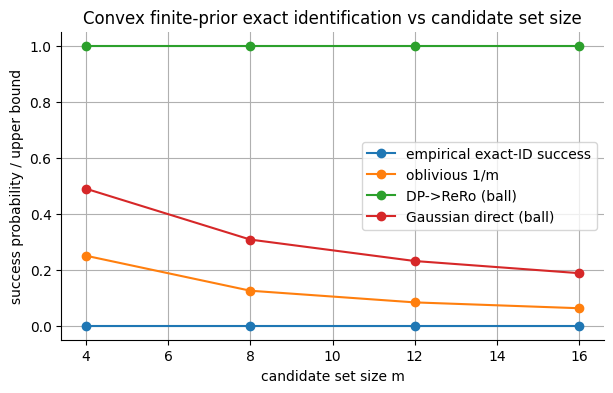

m= 4 | empirical=0.0000 | oblivious=0.2500 | DP->ReRo(ball)=1.0000 | Gaussian direct(ball)=0.4893
m= 8 | empirical=0.0000 | oblivious=0.1250 | DP->ReRo(ball)=1.0000 | Gaussian direct(ball)=0.3076
m=12 | empirical=0.0000 | oblivious=0.0833 | DP->ReRo(ball)=1.0000 | Gaussian direct(ball)=0.2311
m=16 | empirical=0.0000 | oblivious=0.0625 | DP->ReRo(ball)=1.0000 | Gaussian direct(ball)=0.1877


In [101]:
from quantbayes.ball_dp import attack_convex_ball_output_finite_prior, make_finite_identification_prior, ball_rero

m_grid = [4, 8, 12, 16]
m_grid = [m for m in m_grid if m <= len(X_candidates)]

m_vals = []
emp_vals = []
dp_ball_vals = []
dp_std_vals = []
dir_ball_vals = []
dir_std_vals = []

for m in m_grid:
    X_cand_m = np.asarray(X_candidates[:m], dtype=np.float32)
    y_cand_m = np.asarray(y_candidates[:m], dtype=np.int32)
    finite_prior_m = make_finite_identification_prior(X_cand_m, weights=None)

    attack_m, _, _ = attack_convex_ball_output_finite_prior(
        release_convex,
        X_train,
        y_train,
        target_index=target_index,
        X_candidates=X_cand_m,
        y_candidates=y_cand_m,
        prior_weights=None,
        known_label=target_label,
        eta_grid=attack_eta_grid,
    )

    report_dp_m = ball_rero(
        release_convex,
        prior=finite_prior_m,
        eta_grid=(0.5,),
        mode="dp",
    )
    report_dir_m = ball_rero(
        release_convex,
        prior=finite_prior_m,
        eta_grid=(0.5,),
        mode="gaussian_direct",
    )

    p_dp_m = report_dp_m.points[0]
    p_dir_m = report_dir_m.points[0]

    m_vals.append(m)
    emp_vals.append(attack_m.metrics.get("exact_identification_success", np.nan))
    dp_ball_vals.append(p_dp_m.gamma_ball)
    dp_std_vals.append(p_dp_m.gamma_standard)
    dir_ball_vals.append(p_dir_m.gamma_ball)
    dir_std_vals.append(p_dir_m.gamma_standard)

plt.figure(figsize=(7, 4))
plt.plot(m_vals, emp_vals, marker="o", label="empirical exact-ID success")
plt.plot(m_vals, [1.0 / m for m in m_vals], marker="o", label="oblivious 1/m")
plt.plot(m_vals, dp_ball_vals, marker="o", label="DP->ReRo (ball)")
plt.plot(m_vals, dir_ball_vals, marker="o", label="Gaussian direct (ball)")
plt.xlabel("candidate set size m")
plt.ylabel("success probability / upper bound")
plt.title("Convex finite-prior exact identification vs candidate set size")
plt.legend()
plt.show()

for m, emp, dpb, dird in zip(m_vals, emp_vals, dp_ball_vals, dir_ball_vals):
    print(
        f"m={m:>2d} | empirical={emp:.4f} | oblivious={1.0/m:.4f} | "
        f"DP->ReRo(ball)={dpb:.4f} | Gaussian direct(ball)={dird:.4f}"
    )

# Part II — Nonconvex Poisson Ball-SGD

We now switch to the theorem-backed nonconvex release.

We use the one-hidden-layer tanh family covered by the theorem package:
$$
f_\theta(x) = \frac{1}{\sqrt{H}} M^\top \tanh(Wx+b)
$$
with operator-norm constraints.

The privacy workflow is:

1. compute the theorem-backed $L_z$,
2. calibrate a **noise multiplier** to a target $(\varepsilon,\delta)$ using the accountant,
3. train with `privacy="ball_rdp"` so the full Ball-RDP curve is stored,
4. convert the stored RDP curve to Ball-ReRo,
5. also compute the direct Poisson Ball-SGD Ball-ReRo bound.

In [16]:
orders = tuple(range(2, 13))

target_epsilon = 3.0
target_delta = 1e-6

hidden_dim = 128
num_steps = 400          # demo setting; increase for final experiments
batch_size = min(128, len(X_train))
clip_norm = 1.0
learning_rate = 3e-3

spec = TheoremModelSpec(
    d_in=feature_dim,
    hidden_dim=hidden_dim,
    task="multiclass",
    parameterization="dense",
    constraint="op",
    num_classes=num_classes,
)

bounds = TheoremBounds(
    B=B_public,
    A=4.0,
    Lambda=4.0,
)

lz = certified_lz(spec, bounds)

calibration = calibrate_ball_sgd_noise_multiplier(
    dataset_size=len(X_train),
    radius=radius,
    lz=lz,
    num_steps=num_steps,
    batch_size=batch_size,
    clip_norm=clip_norm,
    target_epsilon=target_epsilon,
    delta=target_delta,
    privacy="ball_dp",
    batch_sampler="poisson",
    accountant_subsampling="match_sampler",
    orders=orders,
    lower=1e-3,
    upper=0.25,
    max_upper=128.0,
    num_bisection_steps=12,
)

noise_multiplier = float(calibration["noise_multiplier"])

print("theorem-backed L_z:", lz)
print("calibrated noise multiplier:", noise_multiplier)
print("accountant epsilon at this noise:", calibration["epsilon"])
print("batch sampler:", calibration["batch_sampler"])
print("accountant subsampling:", calibration["accountant_subsampling"])

theorem-backed L_z: 3.394478448847803
calibrated noise multiplier: 1.3505859375
accountant epsilon at this noise: 2.999406507410223
batch sampler: poisson
accountant subsampling: poisson


## Train the theorem-backed Ball-SGD release

Important distinction:

- `privacy="ball_dp"` in the SGD trainer does **not** automatically choose the noise multiplier.
- The recommended workflow is:
  1. calibrate the noise multiplier with the accountant,
  2. train with `privacy="ball_rdp"` and `delta=...`,
  3. keep the full RDP curve and the derived DP certificate.

We also capture:
- public eval curves,
- operator norm history,
- the exact trace information needed for theorem-aligned transcript attacks.

step 1/3000 | clip=1 | noise_multiplier=1.351
step 51/3000 | clip=1 | noise_multiplier=1.351
step 101/3000 | clip=1 | noise_multiplier=1.351
step 151/3000 | clip=1 | noise_multiplier=1.351
step 201/3000 | clip=1 | noise_multiplier=1.351
step 251/3000 | clip=1 | noise_multiplier=1.351
step 301/3000 | clip=1 | noise_multiplier=1.351
step 351/3000 | clip=1 | noise_multiplier=1.351
step 401/3000 | clip=1 | noise_multiplier=1.351
step 451/3000 | clip=1 | noise_multiplier=1.351
step 501/3000 | clip=1 | noise_multiplier=1.351
step 551/3000 | clip=1 | noise_multiplier=1.351
step 601/3000 | clip=1 | noise_multiplier=1.351
step 651/3000 | clip=1 | noise_multiplier=1.351
step 701/3000 | clip=1 | noise_multiplier=1.351
step 751/3000 | clip=1 | noise_multiplier=1.351
step 801/3000 | clip=1 | noise_multiplier=1.351
step 851/3000 | clip=1 | noise_multiplier=1.351
step 901/3000 | clip=1 | noise_multiplier=1.351
step 951/3000 | clip=1 | noise_multiplier=1.351
step 1001/3000 | clip=1 | noise_multiplier=

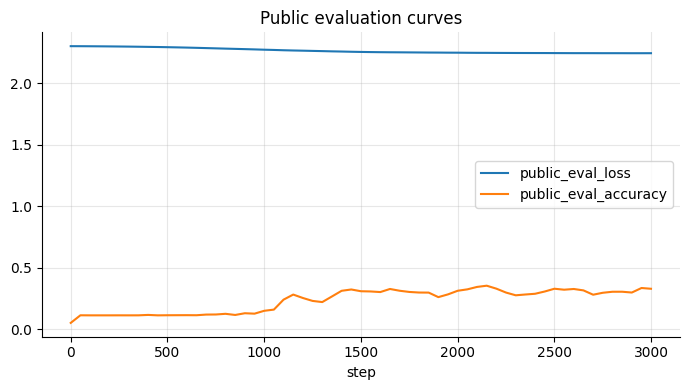

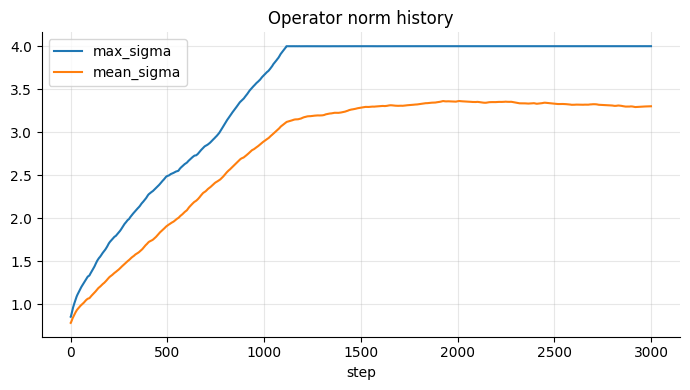

In [37]:
model = make_model(
    spec,
    key=jr.PRNGKey(seed),
    init_project=True,
    bounds=bounds,
)

train_cfg = TrainConfig(
    radius=radius,
    privacy="ball_rdp",
    delta=target_delta,
    num_steps=3000,
    batch_size=256,
    batch_sampler="poisson",
    accountant_subsampling="match_sampler",
    clip_norm=clip_norm,
    noise_multiplier=noise_multiplier,
    learning_rate=learning_rate,
    eval_every=50,
    normalize_noisy_sum_by="batch_size",
    seed=seed,
)

recorder = DPSGDTraceRecorder(
    capture_every=1,
    keep_models=True,
    keep_batch_indices=True,
)

release_nonconvex = fit_release(
    model,
    spec,
    bounds,
    X_train,
    y_train,
    X_eval=X_test,
    y_eval=y_test,
    train_cfg=train_cfg,
    orders=orders,
    trace_recorder=recorder,
    record_operator_norms=True,
    operator_norms_every=1,
)

print("release kind:", release_nonconvex.release_kind)
print("utility:", release_nonconvex.utility_metrics)
print("ball sensitivity Δ_ball (global summary):", release_nonconvex.sensitivity.delta_ball)
print("standard sensitivity Δ_std (global summary):", release_nonconvex.sensitivity.delta_std)

if release_nonconvex.privacy.ball.dp_certificates:
    cert = release_nonconvex.privacy.ball.dp_certificates[0]
    print("derived Ball-DP certificate from stored RDP curve:")
    print("  epsilon =", cert.epsilon)
    print("  delta   =", cert.delta)

plot_release_curves(release_nonconvex)
plot_operator_norm_history(release_nonconvex)

## Inspect the stored Ball-RDP curve

The release stores the full Ball-RDP curve
$$
\alpha \mapsto \varepsilon_{1:T}^{\mathrm{ball}}(\alpha; r)
$$
and the standard comparator curve.

These are the inputs to the optimized Ball-RDP $\to$ Ball-ReRo conversion.

Stored Ball-RDP curve:
  alpha=   2 | eps_ball=12.738207 | eps_std=17.532133
  alpha=   3 | eps_ball=30.515777 | eps_std=54.661918
  alpha=   4 | eps_ball=115.808295 | eps_std=284.722905
  alpha=   5 | eps_ball=446.740278 | eps_std=766.024069
  alpha=   6 | eps_ball=859.278741 | eps_std=1249.127717
  alpha=   7 | eps_ball=1262.722204 | eps_std=1718.256251
  alpha=   8 | eps_ball=1658.027960 | eps_std=2178.746246
  alpha=   9 | eps_ball=2047.943415 | eps_std=2633.768212
  alpha=  10 | eps_ball=2434.217815 | eps_std=3085.136844
  alpha=  11 | eps_ball=2817.935887 | eps_std=3533.947218
  alpha=  12 | eps_ball=3199.793606 | eps_std=3980.896937


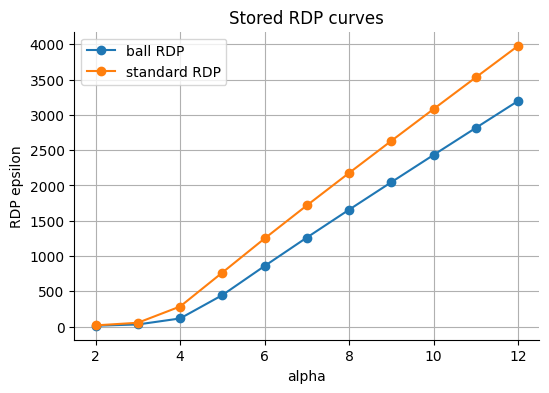

In [29]:
ball_curve = release_nonconvex.privacy.ball.rdp_curve
std_curve = release_nonconvex.privacy.standard.rdp_curve

print("Stored Ball-RDP curve:")
for alpha, eps_ball, eps_std in zip(
    ball_curve.orders,
    ball_curve.epsilons,
    std_curve.epsilons if std_curve is not None else [None] * len(ball_curve.orders),
):
    print(f"  alpha={alpha:>4g} | eps_ball={eps_ball:.6f} | eps_std={eps_std:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(ball_curve.orders, ball_curve.epsilons, marker="o", label="ball RDP")
if std_curve is not None:
    plt.plot(std_curve.orders, std_curve.epsilons, marker="o", label="standard RDP")
plt.xlabel("alpha")
plt.ylabel("RDP epsilon")
plt.title("Stored RDP curves")
plt.legend()
plt.show()

## Prepare the residualized transcript

The theorem-aligned transcript attacks operate on the **residualized sanitized trace**:
the known non-target contribution is subtracted from every retained step.

We then run finite-prior exact Bayes attacks on that residualized trace.

Main attack:
- **unknown inclusion** (`mode="unknown_inclusion"`), which matches the Poisson threat model.

Optional oracle stress test:
- **known inclusion** (`mode="known_inclusion"`).

In [33]:
trace = recorder.to_trace(
    state=None,
    loss_name=spec.loss_name,
    reduction="mean",
    metadata=make_trace_metadata_from_release(
        release_nonconvex,
        target_index=target_index,
    ),
)

residual_trace = subtract_known_batch_gradients(
    trace,
    train_ds,
    target_index=target_index,
)

attack_nonconvex_unknown = attack_nonconvex_ball_trace_finite_prior(
    residual_trace,
    X_candidates,
    y_candidates,
    prior_weights=None,
    cfg=BallTraceMapAttackConfig(
        mode="unknown_inclusion",
        step_mode="present_steps",
        seed=seed,
    ),
    target_index=target_index,
    known_label=target_label,
    true_record=true_record,
    eta_grid=attack_eta_grid,
)

print("UNKNOWN-INCLUSION finite-prior attack")
print("status:", attack_nonconvex_unknown.status)
for k in [
    "exact_identification_success",
    "prior_rank",
    "prior_hit@1",
    "prior_hit@5",
    "oblivious_kappa",
    "feature_l2",
    "feature_cosine",
    "feature_angle_deg",
]:
    if k in attack_nonconvex_unknown.metrics:
        print(f"{k:>26s} :", attack_nonconvex_unknown.metrics[k])

print("selected step count:", attack_nonconvex_unknown.diagnostics.get("selected_step_count"))

UNKNOWN-INCLUSION finite-prior attack
status: ok_known_label
exact_identification_success : 0.0
                prior_rank : 16.0
               prior_hit@1 : 0.0
               prior_hit@5 : 0.0
           oblivious_kappa : 0.0625
                feature_l2 : 0.24263951182365417
            feature_cosine : 0.9705630540847778
         feature_angle_deg : 13.936546250379392
selected step count: 400


In [39]:
attack_nonconvex_known = attack_nonconvex_ball_trace_finite_prior(
    residual_trace,
    X_candidates,
    y_candidates,
    prior_weights=None,
    cfg=BallTraceMapAttackConfig(
        mode="known_inclusion",
        step_mode="present_steps",
        seed=seed,
        num_restarts=1,
        num_steps=10
    ),
    target_index=target_index,
    known_label=target_label,
    true_record=true_record,
    eta_grid=attack_eta_grid,
)

print("KNOWN-INCLUSION finite-prior oracle stress test")
print("status:", attack_nonconvex_known.status)
for k in [
    "exact_identification_success",
    "prior_rank",
    "prior_hit@1",
    "prior_hit@5",
    "oblivious_kappa",
    "feature_l2",
    "feature_cosine",
    "feature_angle_deg",
]:
    if k in attack_nonconvex_known.metrics:
        print(f"{k:>26s} :", attack_nonconvex_known.metrics[k])

print("selected step count:", attack_nonconvex_known.diagnostics.get("selected_step_count"))

ValueError: No retained trace step contains the target index.

## Nonconvex theorem-backed Ball-ReRo from the stored RDP curve

For the finite exact-identification prior with \(m\) uniform candidates,
$$
\kappa=\frac{1}{m}.
$$

The optimized Ball-RDP $\to$ Ball-ReRo theorem gives
$$
\gamma_{\mathrm{RDP}}
=
\inf_{\alpha}
\exp\!\left(
\frac{\alpha-1}{\alpha}\left[-\log m + \varepsilon_{1:T}^{\mathrm{ball}}(\alpha;r)\right]
\right)
$$
truncated at $1$.

This is the theorem-backed bound obtained from the stored RDP curve.

finite-prior exact-ID via Ball-RDP -> Ball-ReRo
  m = 16
  kappa = 1/m = 0.0625
  unknown-inclusion exact-id success = 0.0
  gamma_ball = 0.4342422958891002
  gamma_standard = 0.53696842550958
  alpha_opt_ball = 2.0
  alpha_opt_standard = 2.0


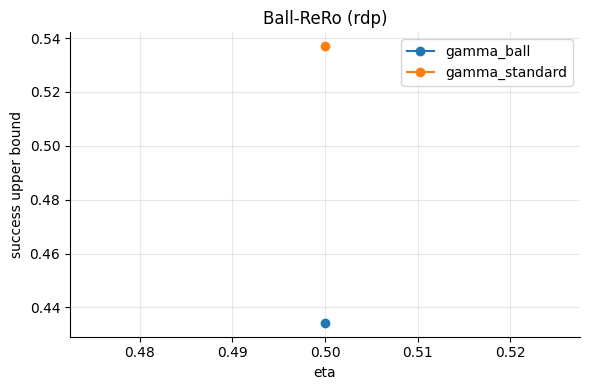

In [49]:
report_nonconvex_rdp = ball_rero(
    release_nonconvex,
    prior=finite_prior,
    eta_grid=finite_eta_grid,
    mode="rdp",
)

p_nonconvex_rdp = report_nonconvex_rdp.points[0]

print("finite-prior exact-ID via Ball-RDP -> Ball-ReRo")
print("  m =", m_candidates)
print("  kappa = 1/m =", p_nonconvex_rdp.kappa)
print("  unknown-inclusion exact-id success =", attack_nonconvex_unknown.metrics.get("exact_identification_success"))
# print("  known-inclusion exact-id success   =", attack_nonconvex_known.metrics.get("exact_identification_success"))
print("  gamma_ball =", p_nonconvex_rdp.gamma_ball)
print("  gamma_standard =", p_nonconvex_rdp.gamma_standard)
print("  alpha_opt_ball =", p_nonconvex_rdp.alpha_opt_ball)
print("  alpha_opt_standard =", p_nonconvex_rdp.alpha_opt_standard)

plot_rero_report(report_nonconvex_rdp)

## Nonconvex direct Poisson Ball-SGD Ball-ReRo

The direct theorem composes one-step profiles
$$
\Gamma_t^{\mathrm{ball}}(\kappa; r) = \Psi_{\gamma_t, \Delta_t(r)/\nu_t}(\kappa)
$$
into
$$
\Gamma_{1:T}^{\mathrm{ball}} = \Gamma_1^{\mathrm{ball}} \circ \cdots \circ \Gamma_T^{\mathrm{ball}}.
$$

For the finite exact-identification prior, we evaluate this composed profile at
$$
\kappa=\frac{1}{m}.
$$

This gives a second theorem-backed upper bound that does **not** go through the RDP curve.

finite-prior exact-ID via direct Poisson Ball-SGD Ball-ReRo
  m = 16
  kappa = 1/m = 0.0625
  unknown-inclusion exact-id success = 0.0
  gamma_ball = 1.0
  gamma_standard = 1.0


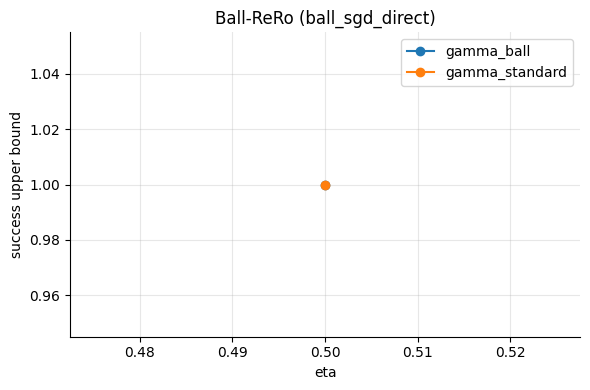

In [48]:
report_nonconvex_direct = ball_rero(
    release_nonconvex,
    prior=finite_prior,
    eta_grid=finite_eta_grid,
    mode="ball_sgd_direct",
)

p_nonconvex_direct = report_nonconvex_direct.points[0]

print("finite-prior exact-ID via direct Poisson Ball-SGD Ball-ReRo")
print("  m =", m_candidates)
print("  kappa = 1/m =", p_nonconvex_direct.kappa)
print("  unknown-inclusion exact-id success =", attack_nonconvex_unknown.metrics.get("exact_identification_success"))
# print("  known-inclusion exact-id success   =", attack_nonconvex_known.metrics.get("exact_identification_success"))
print("  gamma_ball =", p_nonconvex_direct.gamma_ball)
print("  gamma_standard =", p_nonconvex_direct.gamma_standard)

plot_rero_report(report_nonconvex_direct)

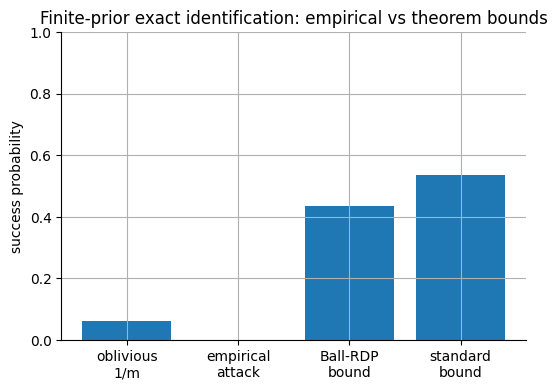

In [47]:
import matplotlib.pyplot as plt

labels = [
    "oblivious\n1/m",
    "empirical\nattack",
    "Ball-RDP\nbound",
    "standard\nbound",
]
values = [
    1.0 / m_candidates,
    attack_nonconvex_unknown.metrics["exact_identification_success"],
    p_nonconvex_rdp.gamma_ball,
    p_nonconvex_rdp.gamma_standard,
]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("success probability")
plt.title("Finite-prior exact identification: empirical vs theorem bounds")
plt.show()

## Inspect the one-step direct-profile diagnostics

The direct theorem stores per-step metadata.

For each step $t$:

- `sample_rate` is $\gamma_t$,
- `sensitivity` is $\Delta_t(r)$,
- `noise_std` is $\nu_t$,
- `c` is $\Delta_t(r)/\nu_t$,
- `tau` is $\Phi(-c/2)$,
- `v` is $2\Phi(c/2)-1$,
- `kappa_left` is $\gamma_t \tau$,
- `kappa_right` is $1-\gamma_t+\gamma_t\tau$.

These are exactly the breakpoints and shape parameters of the one-step profile
$$
\Psi_{\gamma_t,c_t}(\kappa).
$$

In [42]:
step_rows = get_release_step_table(release_nonconvex)

print("first 5 release-step rows:")
for row in step_rows[:5]:
    subset = {
        "step": row["step"],
        "sample_rate": row["sample_rate"],
        "delta_ball": row["delta_ball"],
        "delta_standard": row["delta_standard"],
        "effective_noise_std": row["effective_noise_std"],
        "direct_c_ball": row["direct_c_ball"],
        "direct_tau_ball": row["direct_tau_ball"],
        "direct_kappa_left_ball": row["direct_kappa_left_ball"],
        "direct_kappa_right_ball": row["direct_kappa_right_ball"],
    }
    print(subset)

print("\nfirst direct profile from report metadata:")
print(report_nonconvex_direct.metadata["ball_step_profiles"][0])

first 5 release-step rows:
{'step': 1, 'sample_rate': 0.005333333333333333, 'delta_ball': 1.8456258154330072, 'delta_standard': 2.0, 'effective_noise_std': 1.3505859375, 'direct_c_ball': 1.366537118585249, 'direct_tau_ball': 0.2472185787377919, 'direct_kappa_left_ball': 0.0013184990866015568, 'direct_kappa_right_ball': 0.9959851657532682}
{'step': 2, 'sample_rate': 0.005333333333333333, 'delta_ball': 1.8456258154330072, 'delta_standard': 2.0, 'effective_noise_std': 1.3505859375, 'direct_c_ball': 1.366537118585249, 'direct_tau_ball': 0.2472185787377919, 'direct_kappa_left_ball': 0.0013184990866015568, 'direct_kappa_right_ball': 0.9959851657532682}
{'step': 3, 'sample_rate': 0.005333333333333333, 'delta_ball': 1.8456258154330072, 'delta_standard': 2.0, 'effective_noise_std': 1.3505859375, 'direct_c_ball': 1.366537118585249, 'direct_tau_ball': 0.2472185787377919, 'direct_kappa_left_ball': 0.0013184990866015568, 'direct_kappa_right_ball': 0.9959851657532682}
{'step': 4, 'sample_rate': 0.00

# Nonconvex Poisson Ball-SGD: theorem-backed privacy and reconstruction bounds

We now move from convex Gaussian output perturbation to the nonconvex Poisson Ball-SGD setting.

At each step $t$, we sample a Poisson minibatch with rate
$$
\gamma_t \in (0,1],
$$
compute clipped per-example gradients,
$$
g_t(z) := \nabla_\theta \ell(\theta_t; z),
\qquad
\bar g_t(z) := \operatorname{clip}_C(g_t(z)),
$$
and release a noisy sum
$$
\widetilde S_t(D)
=
\sum_{i\in B_t} \bar g_t(z_i) + \xi_t,
\qquad
\xi_t \sim \mathcal N(0,\nu_t^2 I).
$$

The training transcript is
$$
\mathcal T_T := (\widetilde S_1,\dots,\widetilde S_T),
$$
and the final model is a post-processing of this transcript.

## Ball-local step sensitivity

Under the theorem-backed Lipschitz-in-data constant $L_z$, the clipped gradient difference between two Ball-neighboring records satisfies
$$
\|\bar g_t(z)-\bar g_t(z')\|_2
\le
\min\{L_z r,\ 2C\}.
$$
So the stepwise Ball sensitivity is
$$
\Delta_t(r)
:=
\sup_{d(z,z')\le r}
\|\bar g_t(z)-\bar g_t(z')\|_2
\le
\min\{L_z r,\ 2C\}.
$$

This is the local quantity driving both the privacy accountant and the reconstruction bounds.

---

## Theorem route 1: Ball-SGD-RDP $\Rightarrow$ Ball-ReRo

For each order $\alpha>1$, Poisson subsampling plus Gaussian noise gives a stepwise Ball-RDP cost
$$
\varepsilon_t^{\mathrm{ball}}(\alpha;r),
$$
and adaptive composition yields the transcript-level curve
$$
\varepsilon_{1:T}^{\mathrm{ball}}(\alpha;r)
=
\sum_{t=1}^T \varepsilon_t^{\mathrm{ball}}(\alpha;r).
$$

The generic Ball-RDP $\Rightarrow$ Ball-ReRo theorem then gives
$$
p_{\mathrm{succ}}(\eta)
\le
\inf_{\alpha}
\min\left\{
1,\,
\exp\!\left(
\frac{\alpha-1}{\alpha}
\Big[
\log \kappa(\eta)
+
\varepsilon_{1:T}^{\mathrm{ball}}(\alpha;r)
\Big]
\right)
\right\}.
$$

**Library mode:** `mode="rdp"`

This is the main theorem-backed nonconvex certificate used in the notebook.

---

## Theorem route 2: direct Poisson Ball-SGD $\Rightarrow$ Ball-ReRo

The direct transcript theorem works step-by-step through the one-step profile
$$
\Gamma_t^{\mathrm{ball}}(\kappa;r)
=
\Psi_{\gamma_t,\Delta_t(r)/\nu_t}(\kappa),
$$
and composes these profiles:
$$
\Gamma_{1:T}^{\mathrm{ball}}(\kappa;r)
=
(\Gamma_1^{\mathrm{ball}}\circ\cdots\circ\Gamma_T^{\mathrm{ball}})(\kappa).
$$

The direct Ball-ReRo bound is then
$$
p_{\mathrm{succ}}(\eta)
\le
\Gamma_{1:T}^{\mathrm{ball}}(\kappa(\eta);r).
$$

**Library mode:** `mode="ball_sgd_direct"`

This is also theorem-backed, but in long adaptive transcripts it is often looser than the RDP-based bound.

---

## Threat model: unknown vs. known inclusion

We consider two transcript attacks:

### Unknown inclusion (primary)
The attacker does **not** observe whether the target was sampled at a given step, so target inclusion is treated as a latent Bernoulli variable.

This is the main theorem-aligned threat model for Poisson Ball-SGD.

### Known inclusion (oracle stress test)
The attacker is additionally told which retained steps contain the target.

This is stronger than the default threat model and is best interpreted as an oracle upper-bound stress test.

---

## What “empirical exact” means in the nonconvex finite-prior setting

For a finite prior
$$
\pi_S = \frac1m \sum_{i=1}^m \delta_{z_i},
$$
and exact-identification loss
$$
\rho_{0/1}(z,z') = \mathbb 1\{z\neq z'\},
$$
all $\eta<1$ are equivalent, and the success event is simply
$$
\{\widehat Z = Z\}.
$$

So the empirical exact-identification quantity is
$$
\widehat p_{\mathrm{exact}}
=
\frac1N\sum_{j=1}^N \mathbb 1\{\widehat Z_j = Z_j\}.
$$

When $N=1$, this is just `0.0` or `1.0`.  
When averaged over many targets/seeds, it estimates
$$
\Pr[\widehat Z = Z].
$$

---

## Practical interpretation

In the nonconvex experiments we therefore compare:

- the empirical exact-identification attack success,
- the oblivious baseline $1/m$,
- the optimized **Ball-RDP $\to$ Ball-ReRo** upper bound,
- and the **direct Ball-SGD Ball-ReRo** upper bound.

In practice, the RDP-based route is often the more useful nonconvex certificate.

# Fixed-basis SVD fine-tuning: what rank can and cannot change

We now study a frozen-basis SVD-style private fine-tuning scheme.

The idea is:

1. pretrain a dense public model,
2. extract an orthonormal hidden-layer basis,
3. freeze that basis during private training,
4. fine-tune only the low-dimensional private coefficients together with the bias/output parameters.

Formally, the hidden layer is written in fixed-basis form
$$
W \approx U \,\operatorname{diag}(s)\, V^\top,
$$
where:
- $U$ and $V$ are frozen orthonormal matrices learned from public training,
- $s$ is optimized privately,
- the chosen **rank** controls how many basis directions are retained.

This gives a family of private fine-tuning models indexed by rank.

---

## Why rank might matter empirically

Changing rank changes:

- the private model capacity,
- the approximation quality of the frozen basis,
- the optimization landscape,
- and potentially the empirical attack behavior.

So a rank sweep can reveal utility/attack tradeoffs.

---

## What the current theorem says

In the fixed-basis theorem used in this notebook, the certified Lipschitz-in-data constant
$$
L_z^{(\mathrm{fb})}
$$
depends on the public norm bound and the parameter constraints, but **not on the chosen rank**.

So if we keep the theorem parameters fixed:
- hidden width $H$,
- norm bound $B$,
- coefficient/output constraint $A$,
- spectral/diagonal constraint $\Lambda$,

then changing rank does **not** change the theorem-backed Ball sensitivity certificate.

Consequently, across ranks we expect:
- the same Ball-RDP curve,
- the same RDP $\to$ Ball-ReRo bound,
- the same direct Ball-SGD Ball-ReRo bound.

---

## Therefore, what this rank experiment is testing

This rank sweep is **not** primarily a privacy-certificate frontier.

Instead, it asks:

> If the theorem-backed privacy certificate is held fixed, does changing the frozen private rank improve or degrade utility or empirical reconstruction?

So the rank experiment is best interpreted as a study of:

- utility vs. rank,
- empirical attack behavior vs. rank,
- with a rank-invariant theorem-backed privacy certificate in the background.

---

## What would count as a meaningful result

A meaningful outcome could be one of the following:

1. **No middle-rank advantage:**  
   utility and empirical attack behavior are nearly flat across ranks.

2. **A utility sweet spot:**  
   some intermediate rank gives the best private test performance while keeping the same theorem-backed privacy certificate.

3. **An empirical robustness sweet spot:**  
   some intermediate rank appears harder to attack empirically, even though the certificate is unchanged.

Under the current fixed-basis theorem, any observed rank effect is therefore an **empirical utility/optimization effect**, not a certified privacy effect.

---

## How to read the rank plots

In the plots below:

- the **utility/attack** plot shows whether rank changes actual performance or empirical attack success;
- the **privacy-bound** plot should typically be flat across ranks, because the theorem-backed certificate is rank-independent in this setting.

So if the privacy lines are flat, that is not a bug — it is exactly what the theorem predicts.

## What to report from this notebook

For the thesis, the cleanest primary quantities to report from this notebook are:

### Convex
- utility (`accuracy`),
- Ball vs. standard sensitivity,
- finite-prior exact-identification attack result,
- generic DP Ball-ReRo bound,
- direct Gaussian Ball-ReRo bound.

### Nonconvex
- utility curves,
- operator norm history,
- finite-prior unknown-inclusion attack result,
- finite-prior known-inclusion oracle stress test,
- optimized Ball-RDP $\to$ Ball-ReRo bound,
- direct Poisson Ball-SGD Ball-ReRo bound.

Use the continuous-prior section only as a diagnostic / intuition figure for why
full-dimensional continuous embedding priors are hard to interpret.

In [43]:
demo_summary = {
    "radius": float(radius),
    "feature_dim": int(feature_dim),
    "B_public": float(B_public),
    "target_index": int(target_index),
    "target_label": int(target_label),
    "m_candidates": int(m_candidates),
    "finite_kappa": float(1.0 / m_candidates),

    "convex": {
        "utility": dict(release_convex.utility_metrics),
        "delta_ball": None if release_convex.sensitivity.delta_ball is None else float(release_convex.sensitivity.delta_ball),
        "delta_standard": None if release_convex.sensitivity.delta_std is None else float(release_convex.sensitivity.delta_std),
        "sigma": None if release_convex.privacy.ball.sigma is None else float(release_convex.privacy.ball.sigma),
        "attack_finite": dict(attack_convex_finite.metrics),
        "attack_continuous": dict(attack_convex_cont.metrics),
        "bound_dp_ball": float(p_convex_dp.gamma_ball),
        "bound_gaussian_direct_ball": float(p_convex_dir.gamma_ball),
        "bound_gaussian_direct_standard": None if p_convex_dir.gamma_standard is None else float(p_convex_dir.gamma_standard),
    },

    "nonconvex": {
        "lz": float(lz),
        "noise_multiplier": float(noise_multiplier),
        "utility": dict(release_nonconvex.utility_metrics),
        "attack_unknown": dict(attack_nonconvex_unknown.metrics),
        # "attack_known": dict(attack_nonconvex_known.metrics),
        "bound_rdp_ball": float(p_nonconvex_rdp.gamma_ball),
        "bound_rdp_standard": None if p_nonconvex_rdp.gamma_standard is None else float(p_nonconvex_rdp.gamma_standard),
        "alpha_opt_ball": None if p_nonconvex_rdp.alpha_opt_ball is None else float(p_nonconvex_rdp.alpha_opt_ball),
        "bound_direct_ball": float(p_nonconvex_direct.gamma_ball),
        "bound_direct_standard": None if p_nonconvex_direct.gamma_standard is None else float(p_nonconvex_direct.gamma_standard),
        "first_step_profile": report_nonconvex_direct.metadata["ball_step_profiles"][0],
    },
}

summary_path = RESULTS_DIR / "demo_summary.json"
with open(summary_path, "w") as f:
    json.dump(demo_summary, f, indent=2)

print("saved summary to:", summary_path)
demo_summary

saved summary to: results_ball_dp_demo/demo_summary.json


{'radius': 0.5437141060829163,
 'feature_dim': 512,
 'B_public': 1.0000001192092896,
 'target_index': 17,
 'target_label': 4,
 'm_candidates': 16,
 'finite_kappa': 0.0625,
 'convex': {'utility': {'accuracy': 0.7825},
  'delta_ball': 0.0022560751289747564,
  'delta_standard': 0.008298756176010702,
  'sigma': 0.0034830673472261544,
  'attack_finite': {'distance': 0.2583463191986084,
   'label_correct': 1.0,
   'feature_l2': 0.2583463191986084,
   'feature_cosine': 0.9666285514831543,
   'feature_cosine_error': 0.0333714485168457,
   'feature_angle_rad': 0.25907036542334894,
   'feature_angle_deg': 14.843638535669866,
   'true_feature_norm': 0.9999999403953552,
   'pred_feature_norm': 1.0,
   'success@0.135929': 0.0,
   'success@0.271857': 1.0,
   'success@0.407786': 1.0,
   'success@0.543714': 1.0,
   'oblivious_kappa': 0.0625,
   'mse': 0.00013035706069786102,
   'exact_identification_success': 0.0,
   'prior_exact_hit': 0.0,
   'prior_rank': 10.0,
   'prior_hit@1': 0.0,
   'prior_hit@5

### Evaluating Linear Separability with a Noiseless Logistic Regression Classifier

We test full linear separability in the original 512-dimensional space, we'll train a simple Logistic Regression classifier directly on the embeddings. Its performance will indicate how well the classes can be separated by a linear decision boundary.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

X_np = np.array(X)
y_np = np.array(y_torch)

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

logistic_model = LogisticRegression(max_iter=1000, solver='saga', random_state=42)
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nLogistic Regression Classifier Accuracy: {accuracy:.4f}")


Training data shape: (48000, 512), (48000,)
Testing data shape: (12000, 512), (12000,)

Logistic Regression Classifier Accuracy: 0.9333


A high accuracy score (e.g., >80-90%) from a simple Logistic Regression model would indicate that the embeddings are highly linearly separable and therefore very suitable for various machine learning tasks. If the accuracy is lower, it suggests that either the embeddings are not perfectly linearly separable, or more complex non-linear models would be required to achieve higher performance.

### Loading CIFAR-100 Dataset

We will now load the CIFAR-100 dataset, which is a collection of 60,000 32x32 color images in 100 classes, with 600 images per class. There are 50,000 training images and 10,000 test images.

In [ ]:
import jax.numpy as jnp
import torchvision
import torchvision.transforms as transforms


cifar100_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True), # Resize to ResNet input size
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

# Load the CIFAR-100 training dataset
train_dataset_cifar100 = torchvision.datasets.CIFAR100(
    root='./data_cifar100',
    train=True,
    download=True,
    transform=cifar100_transform
)

# For demonstration, let's take a small subset, e.g., 1000 images.
# This is far less than N=100K, but more realistic for immediate processing.
subset_size = 1000
indices = jr.choice(jr.PRNGKey(42), len(train_dataset_cifar100), (subset_size,), replace=False)

X_cifar_torch = []
y_cifar_torch = []

for i in indices:
    img, label = train_dataset_cifar100[i]
    X_cifar_torch.append(img.numpy()) # Convert to numpy first
    y_cifar_torch.append(label)

# Convert lists to JAX arrays
X_cifar = jnp.array(X_cifar_torch)
y_cifar = jnp.array(y_cifar_torch)

# Print shapes to confirm
print(f"Shape of X (CIFAR-100 images): {X_cifar.shape}")
print(f"Shape of y (CIFAR-100 labels): {y_cifar.shape}")


100%|██████████| 169M/169M [00:05<00:00, 31.4MB/s]


Shape of X (CIFAR-100 images): (1000, 3, 224, 224)
Shape of y (CIFAR-100 labels): (1000,)


### Re-initializing ResNetClassifier for 100 Classes

Since CIFAR-100 has 100 classes, we need to re-initialize our `ResNetClassifier` model with `num_classes=100` instead of 10 (which was used for MNIST). We will load the same pretrained ImageNet weights for the backbone, but adapt the final classification layer.

In [ ]:
import equinox as eqx
import jax.random as jr

from quantbayes.stochax.vision_classification.models import ResNetClassifier
from quantbayes.stochax.vision_common import load_pretrained

# Re-initialize the model for 100 classes (CIFAR-100)
model_cifar, state_cifar = eqx.nn.make_with_state(ResNetClassifier)(
    backbone="resnet18",
    num_classes=100, # Changed to 100 for CIFAR-100
    key=jr.PRNGKey(1),
)

# Load pretrained ImageNet weights, excluding the final classification layer (`strict_fc=False`)
model_cifar = load_pretrained(
    model_cifar,
    npz_path="resnet18_imagenet.npz",
    strict_fc=False, # Set to False to not load the final FC layer weights
)

print("ResNetClassifier re-initialized for 100 classes.")


ResNetClassifier re-initialized for 100 classes.


### Extracting Embeddings for CIFAR-100

Now, let's extract the embeddings for our loaded CIFAR-100 subset using the re-initialized ResNet model. The `extract_embeddings` function will process the images and output 512-dimensional feature vectors.

In [ ]:
import jax.random as jr
from quantbayes.stochax.vision_common import extract_embeddings

key = jr.key(2)

# X_cifar is already in N x C x H x W format with C=3 and H,W=224
# Cast the images to float32 to match the model's expected dtype
X_cifar = X_cifar.astype(jnp.float32)

# Extract embeddings
X_embeddings_cifar = extract_embeddings(
    model_cifar,
    state_cifar,
    X = X_cifar,
    key = key,
    family = "resnet",
    l2_normalize = True
)

print(f"Shape of CIFAR-100 embeddings: {X_embeddings_cifar.shape}")


Shape of CIFAR-100 embeddings: (1000, 512)


# Text Data

In [45]:
# pip install -U datasets sentence-transformers jax jaxlib numpy tqdm torch

from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Optional

import json
import numpy as np
import jax
import jax.numpy as jnp
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import torch


def _default_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def _infer_text_column(column_names: list[str]) -> str:
    candidates = ["text", "content", "sentence", "review", "review_text"]
    for name in candidates:
        if name in column_names:
            return name
    raise ValueError(
        f"Could not infer text column from columns={column_names}. "
        "Pass a dataset with one of: "
        f"{candidates}"
    )


def _maybe_subsample(ds, max_examples: Optional[int], seed: int):
    if max_examples is None or len(ds) <= max_examples:
        return ds
    return ds.shuffle(seed=seed).select(range(max_examples))


def _encode_hf_split(
    ds,
    model: SentenceTransformer,
    *,
    text_col: str,
    label_col: str = "label",
    outer_chunk_size: int = 2048,
    model_batch_size: int = 128,
    normalize_embeddings: bool = True,
    desc: str = "",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Encode a Hugging Face split into a dense float32 matrix and int32 labels.

    Returns
    -------
    X : np.ndarray of shape (n, d), dtype float32
    y : np.ndarray of shape (n,), dtype int32
    """
    n = len(ds)
    y = np.asarray(ds[label_col], dtype=np.int32)

    X = None
    for start in tqdm(range(0, n, outer_chunk_size), desc=desc):
        stop = min(start + outer_chunk_size, n)
        batch_texts = ds[start:stop][text_col]

        batch_emb = model.encode(
            batch_texts,
            batch_size=model_batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=normalize_embeddings,
        )
        batch_emb = np.asarray(batch_emb, dtype=np.float32)

        if X is None:
            d = int(batch_emb.shape[1])
            X = np.empty((n, d), dtype=np.float32)

        X[start:stop] = batch_emb

    assert X is not None
    return X, y


def _to_jax_cpu(x: np.ndarray, dtype) -> jax.Array:
    """
    Keep large arrays on CPU by default; they are still JAX arrays.
    """
    cpu = jax.devices("cpu")[0]
    return jax.device_put(jnp.asarray(x, dtype=dtype), cpu)


def build_yelp_imdb_embeddings(
    *,
    encoder_name: str = "BAAI/bge-small-en-v1.5",
    public_dataset_name: str = "yelp_polarity",
    private_dataset_name: str = "imdb",
    public_split: str = "train",
    private_split: str = "train",
    private_test_split: str = "test",
    max_public_examples: Optional[int] = None,
    max_private_examples: Optional[int] = None,
    max_private_test_examples: Optional[int] = None,
    seed: int = 0,
    device: Optional[str] = None,
    outer_chunk_size: int = 2048,
    model_batch_size: int = 128,
    normalize_embeddings: bool = True,
    hf_cache_dir: Optional[str] = None,
    save_dir: Optional[str] = None,
) -> Dict[str, Any]:
    """
    Build theorem-ready JAX arrays for:
      X_public, y_public, X_priv, y_priv, X_priv_test, y_priv_test

    Notes
    -----
    - Embeddings are L2-normalized when normalize_embeddings=True.
      Then ||x_i||_2 ~= 1 up to floating-point error, so you can take B=1.
    - Arrays are returned as JAX arrays living on CPU by default.
    """
    device = device or _default_device()
    model = SentenceTransformer(encoder_name, device=device)

    public_ds = load_dataset(public_dataset_name, split=public_split, cache_dir=hf_cache_dir)
    private_ds = load_dataset(private_dataset_name, split=private_split, cache_dir=hf_cache_dir)
    private_test_ds = load_dataset(
        private_dataset_name, split=private_test_split, cache_dir=hf_cache_dir
    )

    public_ds = _maybe_subsample(public_ds, max_public_examples, seed)
    private_ds = _maybe_subsample(private_ds, max_private_examples, seed + 1)
    private_test_ds = _maybe_subsample(private_test_ds, max_private_test_examples, seed + 2)

    public_text_col = _infer_text_column(public_ds.column_names)
    private_text_col = _infer_text_column(private_ds.column_names)
    private_test_text_col = _infer_text_column(private_test_ds.column_names)

    X_public_np, y_public_np = _encode_hf_split(
        public_ds,
        model,
        text_col=public_text_col,
        label_col="label",
        outer_chunk_size=outer_chunk_size,
        model_batch_size=model_batch_size,
        normalize_embeddings=normalize_embeddings,
        desc=f"Embedding {public_dataset_name}/{public_split}",
    )

    X_priv_np, y_priv_np = _encode_hf_split(
        private_ds,
        model,
        text_col=private_text_col,
        label_col="label",
        outer_chunk_size=outer_chunk_size,
        model_batch_size=model_batch_size,
        normalize_embeddings=normalize_embeddings,
        desc=f"Embedding {private_dataset_name}/{private_split}",
    )

    X_priv_test_np, y_priv_test_np = _encode_hf_split(
        private_test_ds,
        model,
        text_col=private_test_text_col,
        label_col="label",
        outer_chunk_size=outer_chunk_size,
        model_batch_size=model_batch_size,
        normalize_embeddings=normalize_embeddings,
        desc=f"Embedding {private_dataset_name}/{private_test_split}",
    )

    # Convert to JAX arrays on CPU.
    X_public = _to_jax_cpu(X_public_np, jnp.float32)
    y_public = _to_jax_cpu(y_public_np, jnp.int32)
    X_priv = _to_jax_cpu(X_priv_np, jnp.float32)
    y_priv = _to_jax_cpu(y_priv_np, jnp.int32)
    X_priv_test = _to_jax_cpu(X_priv_test_np, jnp.float32)
    y_priv_test = _to_jax_cpu(y_priv_test_np, jnp.int32)

    result = {
        "X_public": X_public,
        "y_public": y_public,
        "X_priv": X_priv,
        "y_priv": y_priv,
        "X_priv_test": X_priv_test,
        "y_priv_test": y_priv_test,
        "meta": {
            "encoder_name": encoder_name,
            "public_dataset_name": public_dataset_name,
            "private_dataset_name": private_dataset_name,
            "public_split": public_split,
            "private_split": private_split,
            "private_test_split": private_test_split,
            "public_shape": tuple(X_public_np.shape),
            "private_shape": tuple(X_priv_np.shape),
            "private_test_shape": tuple(X_priv_test_np.shape),
            "normalize_embeddings": normalize_embeddings,
            "device_used_for_embedding": device,
            "outer_chunk_size": outer_chunk_size,
            "model_batch_size": model_batch_size,
            "seed": seed,
        },
    }

    if save_dir is not None:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)

        np.savez_compressed(
            save_path / "yelp_imdb_embeddings.npz",
            X_public=X_public_np,
            y_public=y_public_np,
            X_priv=X_priv_np,
            y_priv=y_priv_np,
            X_priv_test=X_priv_test_np,
            y_priv_test=y_priv_test_np,
        )

        with open(save_path / "meta.json", "w", encoding="utf-8") as f:
            json.dump(result["meta"], f, indent=2)

    return result


if __name__ == "__main__":
    data = build_yelp_imdb_embeddings(
        encoder_name="BAAI/bge-small-en-v1.5",
        public_dataset_name="yelp_polarity",
        private_dataset_name="imdb",
        public_split="train",
        private_split="train",
        private_test_split="test",
        # Set these to None for the full datasets.
        # For a quick smoke test, try 10_000 / 2_000 / 2_000 first.
        max_public_examples=None,
        max_private_examples=None,
        max_private_test_examples=None,
        seed=0,
        outer_chunk_size=2048,
        model_batch_size=128,
        normalize_embeddings=True,
        save_dir="data/yelp_imdb_bge_small_en_v1_5",
    )

    X_public = data["X_public"]
    y_public = data["y_public"]
    X_priv = data["X_priv"]
    y_priv = data["y_priv"]
    X_priv_test = data["X_priv_test"]
    y_priv_test = data["y_priv_test"]

    print("X_public:", X_public.shape, X_public.dtype)
    print("y_public:", y_public.shape, y_public.dtype)
    print("X_priv:", X_priv.shape, X_priv.dtype)
    print("y_priv:", y_priv.shape, y_priv.dtype)
    print("X_priv_test:", X_priv_test.shape, X_priv_test.dtype)
    print("y_priv_test:", y_priv_test.shape, y_priv_test.dtype)

    # Optional sanity check: because normalize_embeddings=True,
    # norms should be ~1.
    public_norms = np.linalg.norm(np.asarray(X_public[:1024]), axis=1)
    print("public norm range:", float(public_norms.min()), float(public_norms.max()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Embedding yelp_polarity/train:   0%|          | 0/274 [00:00<?, ?it/s]

Embedding imdb/train:   0%|          | 0/13 [00:00<?, ?it/s]

Embedding imdb/test:   0%|          | 0/13 [00:00<?, ?it/s]

X_public: (560000, 384) float32
y_public: (560000,) int32
X_priv: (25000, 384) float32
y_priv: (25000,) int32
X_priv_test: (25000, 384) float32
y_priv_test: (25000,) int32
public norm range: 0.9999998807907104 1.0000001192092896


### Visualize Text Embeddings using PCA (2D and 3D)

Performing 2D PCA...


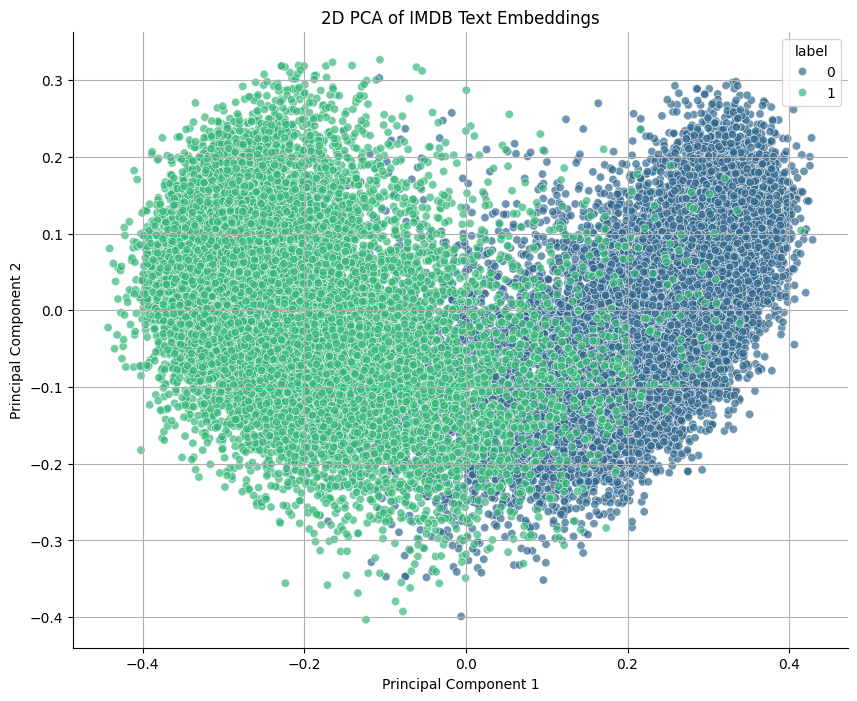


Performing 3D PCA...


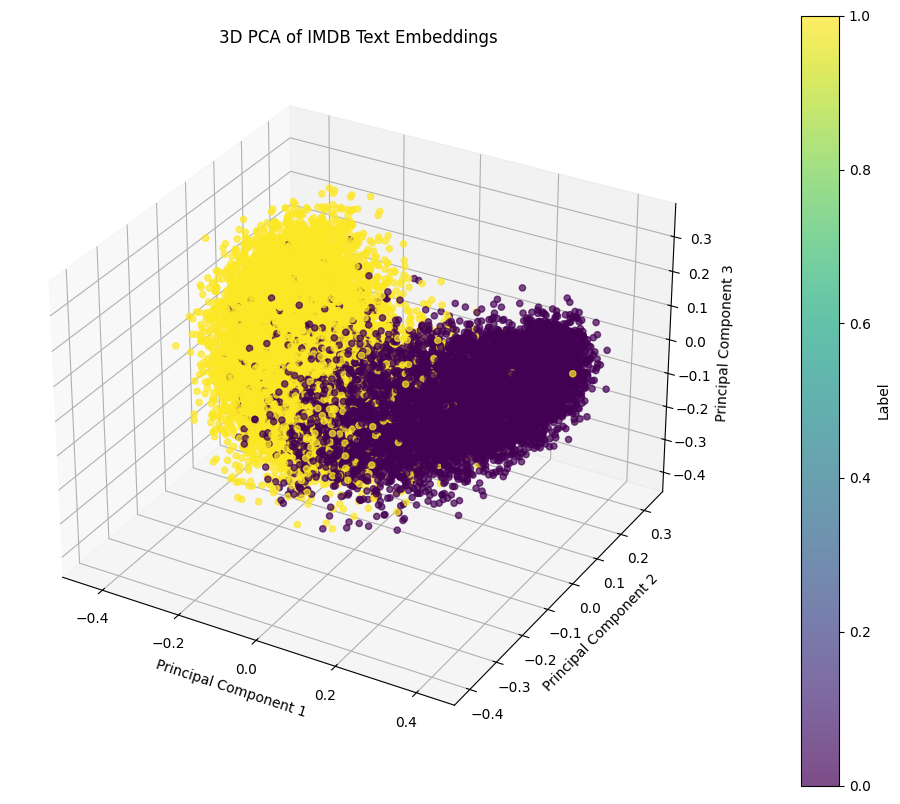

In [46]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Using X_priv and y_priv for visualization as an example
X_np_text = np.array(X_priv)
y_np_text = np.array(y_priv)

# --- 2D PCA Visualization ---
print("Performing 2D PCA...")
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_np_text)

pca_df_2d = pd.DataFrame(data=X_pca_2d, columns=['principal_component_1', 'principal_component_2'])
pca_df_2d['label'] = y_np_text

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='label',
    palette='viridis',
    data=pca_df_2d,
    legend='full',
    alpha=0.7
)
plt.title('2D PCA of IMDB Text Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# --- 3D PCA Visualization ---
print("\nPerforming 3D PCA...")
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_np_text)

pca_df_3d = pd.DataFrame(data=X_pca_3d, columns=['principal_component_1', 'principal_component_2', 'principal_component_3'])
pca_df_3d['label'] = y_np_text

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df_3d['principal_component_1'],
    pca_df_3d['principal_component_2'],
    pca_df_3d['principal_component_3'],
    c=pca_df_3d['label'],
    cmap='viridis',
    alpha=0.7,
    s=20 # marker size
)

ax.set_title('3D PCA of IMDB Text Embeddings')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add a color bar to show the mapping of colors to labels
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Label')

plt.show()

# Part III — The theorem-backed nonconvex path with optional SVD fine-tuning

  

This section demonstrates the full theorem-facing workflow on a public/private split.

  

We assume the following arrays already exist:

  

```python

X_public

y_public

X_priv

y_priv

X_priv_test

y_priv_test

```

  

The three groups are:

  

1.  **private-only end-to-end** training,

2.  **public dense pretrain $\to$ private dense fine-tune**,

3.  **public dense pretrain $\to$ frozen-basis SVD private fine-tune** for multiple ranks.

  

The theorem-facing family used here is the one-hidden-layer tanh model with operator-norm control.

For the fixed-basis SVD family, the theorem-backed certified $L_z$ is independent of the rank at fixed

$(H, A, \Lambda, B)$, so rank mainly changes utility and attacks, not the privacy certificate.

In [52]:
import json

from pathlib import Path



import jax.random as jr

import matplotlib.pyplot as plt

import numpy as np

from sklearn.model_selection import train_test_split



from quantbayes.ball_dp import (
    ArrayDataset,
    attack_nonconvex_ball_trace_finite_prior,
    ball_rero,
    get_operator_norm_history,
    get_public_curve_history,
    get_release_step_table,
    make_finite_identification_prior,
    make_trace_metadata_from_release,
    plot_operator_norm_history,
    plot_release_curves,
    select_ball_radius,
    summarize_embedding_ball_radii,
)

from quantbayes.ball_dp.api import (
    calibrate_ball_sgd_noise_multiplier,
    evaluate_release_classifier,

)

from quantbayes.ball_dp.attacks.ball_policy import BallTraceMapAttackConfig

from quantbayes.ball_dp.attacks.gradient_based import (
    DPSGDTraceRecorder,
    subtract_known_batch_gradients,

)

from quantbayes.ball_dp.theorem import (
    TheoremBounds,
    TheoremModelSpec,
    TrainConfig,
    certified_lz,
    fit_release,
    load_dense_checkpoint_as_svd,
    load_model_checkpoint,
    make_model,
    replace_dense_with_svd,
    save_model_checkpoint,
)



THEOREM_RESULTS_DIR = Path("results_ball_dp_theorem_svd_demo")

THEOREM_RESULTS_DIR.mkdir(exist_ok=True)


plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Private/public setup and theorem constants
We:
- split the public data into `public_train` / `public_val`,

- compute a private Ball radius from within-label private geometry,

- build a finite exact-identification prior for a private target,

- choose one theorem family and one public bound set.

  
For this demo we use the **multiclass dense operator-norm family**

  

a) because it is theorem-backed,

  

b) because it warm-starts cleanly into the fixed-basis SVD family.


In [67]:
def choose_target_index(y_train, y_pool, *, preferred=17, min_pool_per_label=8):
    preferred = int(preferred)

    if 0 <= preferred < len(y_train):
        if np.sum(y_pool == y_train[preferred]) >= int(min_pool_per_label):
            return preferred

    for idx in range(len(y_train)):
        if np.sum(y_pool == y_train[idx]) >= int(min_pool_per_label):
            return idx

    raise ValueError(
        "Could not find a target with enough same-label held-out candidates."
    )


def build_same_label_finite_support(
    x_target, target_label, X_pool, y_pool, *, max_candidates=16
):
    x_target = np.asarray(x_target, dtype=np.float32).reshape(-1)

    mask = np.asarray(y_pool) == int(target_label)
    pool = np.asarray(X_pool[mask], dtype=np.float32).reshape(np.sum(mask), -1)

    if len(pool) == 0:
        raise ValueError("No same-label held-out candidates available.")

    dists = np.linalg.norm(pool - x_target[None, :], axis=1)
    order = np.argsort(dists)

    chosen = []
    for j in order:
        cand = np.asarray(pool[j], dtype=np.float32)
        if np.allclose(cand, x_target, atol=1e-8, rtol=0.0):
            continue
        chosen.append(cand)
        if len(chosen) >= int(max_candidates) - 1:
            break

    chosen.append(x_target)

    uniq = []
    for z in chosen:
        if not any(np.allclose(z, u, atol=1e-8, rtol=0.0) for u in uniq):
            uniq.append(np.asarray(z, dtype=np.float32))

    X_candidates = np.stack(uniq, axis=0)
    y_candidates = np.full((len(X_candidates),), int(target_label), dtype=np.int32)
    return X_candidates, y_candidates


X_public = np.asarray(X_public, dtype=np.float32)
y_public = np.asarray(y_public)
X_priv = np.asarray(X_priv, dtype=np.float32)
y_priv = np.asarray(y_priv)
X_priv_test = np.asarray(X_priv_test, dtype=np.float32)
y_priv_test = np.asarray(y_priv_test)

if X_public.ndim != 2:
    X_public = X_public.reshape(len(X_public), -1)
if X_priv.ndim != 2:
    X_priv = X_priv.reshape(len(X_priv), -1)
if X_priv_test.ndim != 2:
    X_priv_test = X_priv_test.reshape(len(X_priv_test), -1)

# Re-encode labels once across all three splits so the theorem family sees
# a consistent class index set.
all_labels = np.concatenate(
    [
        np.asarray(y_public).reshape(-1),
        np.asarray(y_priv).reshape(-1),
        np.asarray(y_priv_test).reshape(-1),
    ]
)

label_values, y_encoded = np.unique(all_labels, return_inverse=True)
n_pub = len(y_public)
n_priv = len(y_priv)

y_public = y_encoded[:n_pub].astype(np.int32)
y_priv = y_encoded[n_pub : n_pub + n_priv].astype(np.int32)
y_priv_test = y_encoded[n_pub + n_priv :].astype(np.int32)

seed = 0
orders = tuple(range(2, 13))

X_public_train, X_public_val, y_public_train, y_public_val = train_test_split(
    X_public,
    y_public,
    test_size=0.1,
    random_state=42,
    stratify=y_public,
)

num_classes = int(len(np.unique(np.concatenate([y_public, y_priv, y_priv_test]))))
feature_dim = int(X_priv.shape[1])

B_all = float(
    max(
        np.max(np.linalg.norm(X_public_train, axis=1)),
        np.max(np.linalg.norm(X_public_val, axis=1)),
        np.max(np.linalg.norm(X_priv, axis=1)),
        np.max(np.linalg.norm(X_priv_test, axis=1)),
    )
)

radius_report_priv = summarize_embedding_ball_radii(
    X_priv,
    y_priv,
    quantiles=(0.5, 0.8, 0.9, 0.95, 0.99, 1.0),
    max_exact_pairs=250_000,
    max_sampled_pairs=100_000,
    seed=seed,
)

radius_priv = select_ball_radius(
    radius_report_priv,
    strategy="max_labelwise_quantile",
    quantile=0.50,
)
radius_priv = 0.1
priv_train_ds = ArrayDataset(X_priv, y_priv, name="priv_train")
priv_test_ds = ArrayDataset(X_priv_test, y_priv_test, name="priv_test")

target_index = choose_target_index(
    y_priv,
    y_priv_test,
    preferred=17,
    min_pool_per_label=8,
)
target_label = int(y_priv[target_index])
x_target = np.asarray(X_priv[target_index], dtype=np.float32).reshape(-1)
true_record = priv_train_ds.record(target_index)

X_candidates, y_candidates = build_same_label_finite_support(
    x_target,
    target_label,
    X_priv_test,
    y_priv_test,
    max_candidates=16,
)

finite_prior = make_finite_identification_prior(X_candidates, weights=None)
m_candidates = int(len(X_candidates))

print("X_public_train shape:", X_public_train.shape)
print("X_public_val shape:", X_public_val.shape)
print("X_priv shape:", X_priv.shape)
print("X_priv_test shape:", X_priv_test.shape)
print("feature_dim:", feature_dim)
print("num_classes:", num_classes)
print("private radius r:", float(radius_priv))
print("B_all:", B_all)
print("target_index:", target_index)
print("target_label:", target_label)
print("finite prior size m:", m_candidates)
print("exact-identification oblivious baseline 1/m:", 1.0 / m_candidates)

X_public_train shape: (504000, 384)
X_public_val shape: (56000, 384)
X_priv shape: (25000, 384)
X_priv_test shape: (25000, 384)
feature_dim: 384
num_classes: 2
private radius r: 0.1
B_all: 1.0000001192092896
target_index: 17
target_label: 0
finite prior size m: 16
exact-identification oblivious baseline 1/m: 0.0625


## Common theorem model, privacy target, and helper functions

  

We use one common dense operator-norm theorem family and one common private training schedule.

The private stages differ only in initialization / parameterization.

  

This is deliberate: it makes the privacy side directly comparable across groups.

In particular, if `hidden_dim`, `A`, `Lambda`, `B`, `r`, and the SGD schedule are fixed, then the theorem-backed privacy bound is expected to be flat across the SVD rank sweep.


In [68]:
dense_spec = TheoremModelSpec(
    d_in=feature_dim,
    hidden_dim=128,
    task="binary",
    parameterization="dense",
    constraint="op",
    # num_classes=num_classes,
)

bounds_op = TheoremBounds(B=B_all, A=4.0, Lambda=4.0)
lz_dense = certified_lz(dense_spec, bounds_op)

private_num_steps = 300
public_num_steps = 250
private_batch_size = min(128, len(X_priv))
public_batch_size = min(128, len(X_public_train))
private_eval_every = 25
learning_rate = 3e-3

# Choose a clip norm tied to the theorem sensitivity scale, but not absurdly small.
clip_norm = float(max(0.25, min(1.0, 0.75 * lz_dense * radius_priv)))

target_epsilon = 3.0
target_delta = 1e-6

calibration = calibrate_ball_sgd_noise_multiplier(
    dataset_size=len(X_priv),
    radius=radius_priv,
    lz=lz_dense,
    num_steps=private_num_steps,
    batch_size=private_batch_size,
    clip_norm=clip_norm,
    target_epsilon=target_epsilon,
    delta=target_delta,
    privacy="ball_dp",
    batch_sampler="poisson",
    accountant_subsampling="match_sampler",
    orders=orders,
    lower=1e-3,
    upper=0.25,
    max_upper=128.0,
    num_bisection_steps=12,
)

noise_multiplier = float(calibration["noise_multiplier"])

private_train_cfg = TrainConfig(
    radius=radius_priv,
    privacy="ball_rdp",
    delta=target_delta,
    num_steps=private_num_steps,
    batch_size=private_batch_size,
    batch_sampler="poisson",
    accountant_subsampling="match_sampler",
    clip_norm=clip_norm,
    noise_multiplier=noise_multiplier,
    learning_rate=learning_rate,
    checkpoint_selection="last",  # do not use private test for model selection
    eval_every=private_eval_every,
    seed=seed,
)

public_train_cfg = TrainConfig(
    radius=radius_priv,
    privacy="noiseless",
    num_steps=public_num_steps,
    batch_size=public_batch_size,
    clip_norm=clip_norm,
    noise_multiplier=0.0,
    learning_rate=learning_rate,
    checkpoint_selection="best_public_eval_accuracy",
    eval_every=25,
    seed=seed,
)

attack_eta_grid = tuple(float(radius_priv * q) for q in (0.25, 0.50, 0.75, 1.00))
finite_eta_grid = (0.5,)

print("dense theorem L_z:", lz_dense)
print("clip_norm:", clip_norm)
print("calibrated noise multiplier:", noise_multiplier)
print("accountant epsilon at this noise:", calibration["epsilon"])
print("orders:", orders)

dense theorem L_z: 2.2365264409661334
clip_norm: 0.25
calibrated noise multiplier: 0.7342529296875
accountant epsilon at this noise: 2.997447446211729
orders: (2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)


In [69]:
def run_private_release_bundle(
    name,
    model,
    spec,
    bounds,
    *,
    state=None,
    trainable="default",
    seed=0,
):
    recorder = DPSGDTraceRecorder(
        capture_every=1,
        keep_models=True,
        keep_batch_indices=True,
    )

    release = fit_release(
        model,
        spec,
        bounds,
        X_priv,
        y_priv,
        X_eval=X_priv_test,
        y_eval=y_priv_test,
        train_cfg=private_train_cfg,
        state=state,
        trainable=trainable,
        trace_recorder=recorder,
        record_operator_norms=True,
        operator_norms_every=private_eval_every,
    )

    private_eval = evaluate_release_classifier(release, X_priv_test, y_priv_test)

    trace = recorder.to_trace(
        state=release.extra.get("model_state", None),
        loss_name=spec.loss_name,
        reduction="mean",
        metadata=make_trace_metadata_from_release(
            release,
            target_index=target_index,
        ),
    )
    residual_trace = subtract_known_batch_gradients(
        trace,
        priv_train_ds,
        target_index=target_index,
    )

    attack_unknown = attack_nonconvex_ball_trace_finite_prior(
        residual_trace,
        X_candidates,
        y_candidates,
        prior_weights=None,
        cfg=BallTraceMapAttackConfig(
            mode="unknown_inclusion",
            step_mode="present_steps",
            seed=seed,
        ),
        target_index=target_index,
        known_label=target_label,
        true_record=true_record,
        eta_grid=attack_eta_grid,
    )

    report_rdp = ball_rero(
        release,
        prior=finite_prior,
        eta_grid=finite_eta_grid,
        mode="rdp",
    )

    report_direct = ball_rero(
        release,
        prior=finite_prior,
        eta_grid=finite_eta_grid,
        mode="ball_sgd_direct",
    )

    return {
        "name": str(name),
        "spec": spec,
        "release": release,
        "private_eval": private_eval,
        "attack_unknown": attack_unknown,
        "report_rdp": report_rdp,
        "report_direct": report_direct,
    }


def extract_curve_xy(history, value_key):
    steps = []
    values = []

    for row in history:
        val = row.get(value_key, None)
        if val is None:
            continue
        steps.append(float(row["step"]))
        values.append(float(val))

    return np.asarray(steps, dtype=np.float64), np.asarray(values, dtype=np.float64)


def extract_max_sigma_curve(release):
    history = get_operator_norm_history(release)

    steps = []
    values = []

    for row in history:
        summary = row.get("summary", {}) or {}
        val = summary.get("max_sigma", None)
        if val is None:
            continue
        steps.append(float(row["step"]))
        values.append(float(val))

    return np.asarray(steps, dtype=np.float64), np.asarray(values, dtype=np.float64)


def summarize_bundle(bundle):
    p_rdp = bundle["report_rdp"].points[0]
    p_dir = bundle["report_direct"].points[0]

    return {
        "name": bundle["name"],
        "final_private_test_accuracy": float(
            bundle["private_eval"].get("accuracy", np.nan)
        ),
        "attack_unknown_exact_id": float(
            bundle["attack_unknown"].metrics.get(
                "exact_identification_success",
                np.nan,
            )
        ),
        "gamma_rdp_ball": float(p_rdp.gamma_ball),
        "gamma_rdp_standard": (
            None if p_rdp.gamma_standard is None else float(p_rdp.gamma_standard)
        ),
        "alpha_opt_ball": (
            None if p_rdp.alpha_opt_ball is None else float(p_rdp.alpha_opt_ball)
        ),
        "gamma_direct_ball": float(p_dir.gamma_ball),
        "gamma_direct_standard": (
            None if p_dir.gamma_standard is None else float(p_dir.gamma_standard)
        ),
    }

## Group 1 — private-only end-to-end training

  

This is the baseline theorem-backed private training run from scratch.

It fixes the private Ball-SGD schedule and gives us:

  

- utility curves,

- operator-norm curves,

- finite-prior transcript attacks,

- optimized Ball-RDP $\to$ Ball-ReRo,

- direct Poisson Ball-SGD Ball-ReRo.

step 1/300 | clip=0.25 | noise_multiplier=0.7343
step 26/300 | clip=0.25 | noise_multiplier=0.7343
step 51/300 | clip=0.25 | noise_multiplier=0.7343
step 76/300 | clip=0.25 | noise_multiplier=0.7343
step 101/300 | clip=0.25 | noise_multiplier=0.7343
step 126/300 | clip=0.25 | noise_multiplier=0.7343
step 151/300 | clip=0.25 | noise_multiplier=0.7343
step 176/300 | clip=0.25 | noise_multiplier=0.7343
step 201/300 | clip=0.25 | noise_multiplier=0.7343
step 226/300 | clip=0.25 | noise_multiplier=0.7343
step 251/300 | clip=0.25 | noise_multiplier=0.7343
step 276/300 | clip=0.25 | noise_multiplier=0.7343
step 300/300 | clip=0.25 | noise_multiplier=0.7343
{
  "name": "group1_private_only_dense",
  "final_private_test_accuracy": 0.92528,
  "attack_unknown_exact_id": 0.0,
  "gamma_rdp_ball": 0.12727579297346578,
  "gamma_rdp_standard": 1.0,
  "alpha_opt_ball": 5.0,
  "gamma_direct_ball": 0.7653838582887923,
  "gamma_direct_standard": 1.0
}


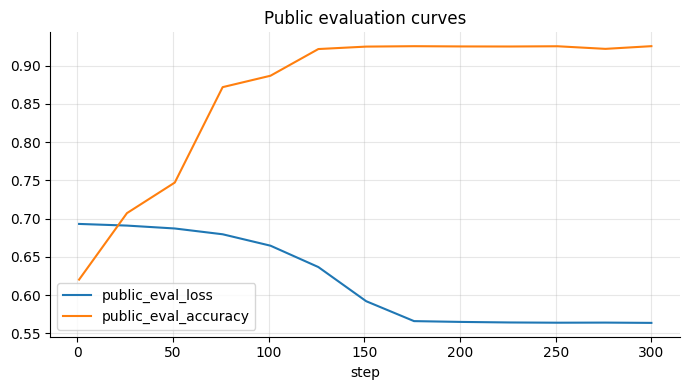

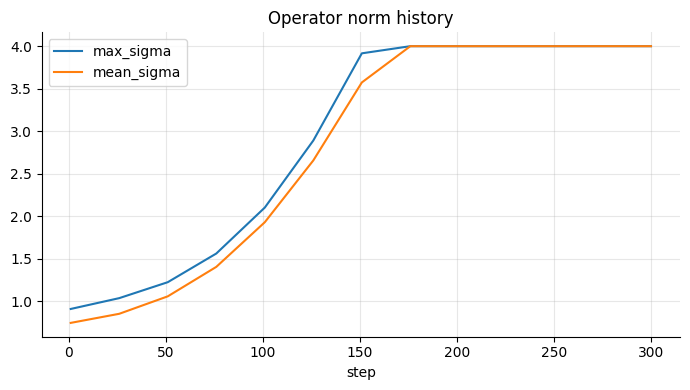

first step profile: {'step': 1, 'sample_rate': 0.00512, 'sensitivity': 0.22365264409661334, 'noise_std': 0.183563232421875, 'c': 1.2183956511650584, 'tau': 0.2711966607132851, 'v': 0.45760667857342985, 'kappa_left': 0.0013885269028520197, 'kappa_right': 0.9962685269028521}


In [70]:
model_g1 = make_model(
    dense_spec,
    key=jr.PRNGKey(seed),
    init_project=True,
    bounds=bounds_op,
)

bundle_g1 = run_private_release_bundle(
    "group1_private_only_dense",
    model_g1,
    dense_spec,
    bounds_op,
    state=None,
    trainable="default",
    seed=seed,
)

print(json.dumps(summarize_bundle(bundle_g1), indent=2))
plot_release_curves(bundle_g1["release"])
plot_operator_norm_history(bundle_g1["release"])
print(
    "first step profile:",
    bundle_g1["report_direct"].metadata["ball_step_profiles"][0],
)

## Group 2 — public dense pretrain $\to$ private dense fine-tune

  

We first train a noiseless public model, then continue training on the private data under the same private Ball-SGD schedule as Group 1.

  

This isolates the effect of a good public warm start.

step 1/250 | clip=0.25 | noise_multiplier=0
step 26/250 | clip=0.25 | noise_multiplier=0
step 51/250 | clip=0.25 | noise_multiplier=0
step 76/250 | clip=0.25 | noise_multiplier=0
step 101/250 | clip=0.25 | noise_multiplier=0
step 126/250 | clip=0.25 | noise_multiplier=0
step 151/250 | clip=0.25 | noise_multiplier=0
step 176/250 | clip=0.25 | noise_multiplier=0
step 201/250 | clip=0.25 | noise_multiplier=0
step 226/250 | clip=0.25 | noise_multiplier=0
step 250/250 | clip=0.25 | noise_multiplier=0
public dense pretrain utility: {'public_eval_loss': 0.6097107740129744, 'accuracy': 0.9375714285714286, 'public_eval_accuracy': 0.9375714285714286}


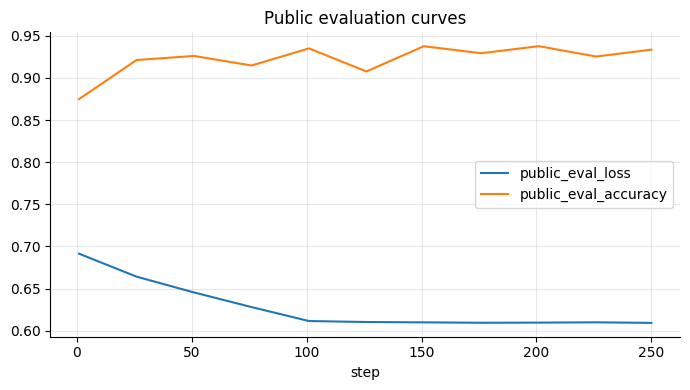

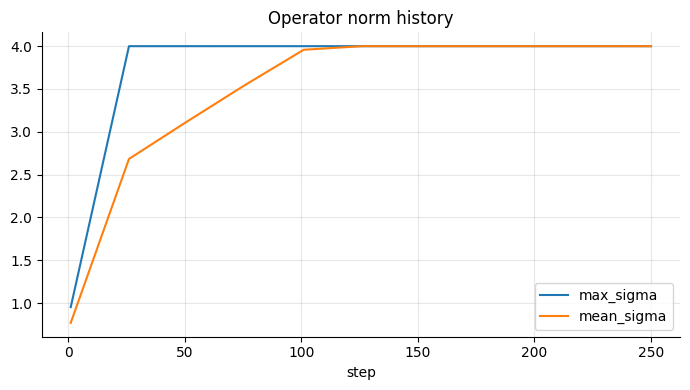

In [71]:
public_model_dense = make_model(
    dense_spec,
    key=jr.PRNGKey(seed + 1),
    init_project=True,
    bounds=bounds_op,
)

public_release_dense = fit_release(
    public_model_dense,
    dense_spec,
    bounds_op,
    X_public_train,
    y_public_train,
    X_eval=X_public_val,
    y_eval=y_public_val,
    train_cfg=public_train_cfg,
    record_operator_norms=True,
    operator_norms_every=25,
)

print("public dense pretrain utility:", public_release_dense.utility_metrics)
plot_release_curves(public_release_dense)
plot_operator_norm_history(public_release_dense)

## Optional checkpoint cell

  

This cell shows the theorem checkpoint API.

It is not required for the rest of the notebook, but it is useful for reproducible public pretraining and later SVD conversion from disk.


In [72]:
ckpt_dir = THEOREM_RESULTS_DIR / "public_dense_ckpt"

save_model_checkpoint(
    public_release_dense.payload,
    dense_spec,
    ckpt_dir,
    state=public_release_dense.extra.get("model_state", None),
    metadata={"stage": "public_pretrain_dense"},
)

loaded_dense_model, loaded_dense_spec, loaded_dense_state, loaded_dense_meta = (
    load_model_checkpoint(ckpt_dir)
)

svd_model_ckpt, svd_spec_ckpt, svd_state_ckpt, svd_meta_ckpt = (
    load_dense_checkpoint_as_svd(
        ckpt_dir,
        rank=min(32, dense_spec.hidden_dim, dense_spec.d_in),
        bounds=bounds_op,
        init_project=True,
    )
)

print("saved checkpoint to:", ckpt_dir)
print("loaded dense spec:", loaded_dense_spec)
print("loaded metadata:", loaded_dense_meta)
print("loaded svd spec:", svd_spec_ckpt)

saved checkpoint to: results_ball_dp_theorem_svd_demo/public_dense_ckpt
loaded dense spec: TheoremModelSpec(d_in=384, hidden_dim=128, task='binary', num_classes=None, parameterization='dense', constraint='op', rank=None)
loaded metadata: {'stage': 'public_pretrain_dense'}
loaded svd spec: TheoremModelSpec(d_in=384, hidden_dim=128, task='binary', num_classes=None, parameterization='svd', constraint='op', rank=32)


step 1/300 | clip=0.25 | noise_multiplier=0.7343
step 26/300 | clip=0.25 | noise_multiplier=0.7343
step 51/300 | clip=0.25 | noise_multiplier=0.7343
step 76/300 | clip=0.25 | noise_multiplier=0.7343
step 101/300 | clip=0.25 | noise_multiplier=0.7343
step 126/300 | clip=0.25 | noise_multiplier=0.7343
step 151/300 | clip=0.25 | noise_multiplier=0.7343
step 176/300 | clip=0.25 | noise_multiplier=0.7343
step 201/300 | clip=0.25 | noise_multiplier=0.7343
step 226/300 | clip=0.25 | noise_multiplier=0.7343
step 251/300 | clip=0.25 | noise_multiplier=0.7343
step 276/300 | clip=0.25 | noise_multiplier=0.7343
step 300/300 | clip=0.25 | noise_multiplier=0.7343
{
  "name": "group2_public_to_private_dense",
  "final_private_test_accuracy": 0.9256,
  "attack_unknown_exact_id": 0.0,
  "gamma_rdp_ball": 0.12727579297346578,
  "gamma_rdp_standard": 1.0,
  "alpha_opt_ball": 5.0,
  "gamma_direct_ball": 0.7653838582887923,
  "gamma_direct_standard": 1.0
}


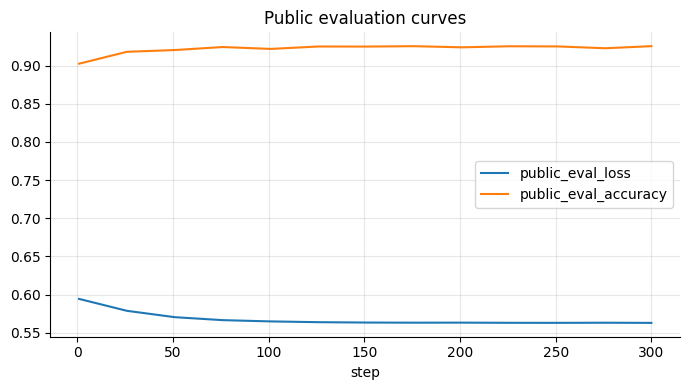

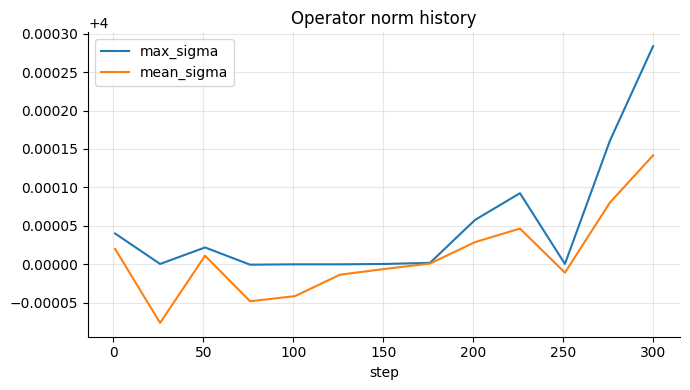

In [73]:
bundle_g2 = run_private_release_bundle(
    "group2_public_to_private_dense",
    public_release_dense.payload,
    dense_spec,
    bounds_op,
    state=public_release_dense.extra.get("model_state", None),
    trainable="default",
    seed=seed + 2,
)

print(json.dumps(summarize_bundle(bundle_g2), indent=2))
plot_release_curves(bundle_g2["release"])
plot_operator_norm_history(bundle_g2["release"])

## Group 3 — public dense pretrain \(\to\) frozen-basis SVD private fine-tune

  

We convert the public dense hidden layer into a fixed-basis SVD layer and then fine-tune privately.

The default theorem-safe trainable set is:

  

- singular values `s`,

- hidden bias,

- output head.

  

The orthonormal basis matrices `U, V` remain frozen.

  

We sweep multiple ranks. At fixed $(H, A, \Lambda, B)$, the certified theorem constant is expected to be rank-independent.

In [74]:
candidate_ranks = [
    r
    for r in (8, 16, 32, 64)
    if r <= min(dense_spec.hidden_dim, dense_spec.d_in)
]

if not candidate_ranks:
    candidate_ranks = [int(min(dense_spec.hidden_dim, dense_spec.d_in))]

print("candidate ranks:", candidate_ranks)
print("rank -> certified L_z")

for r in candidate_ranks:
    svd_spec = dense_spec.to_svd(rank=r)
    print(r, certified_lz(svd_spec, bounds_op))

candidate ranks: [8, 16, 32, 64]
rank -> certified L_z
8 2.2365264409661334
16 2.2365264409661334
32 2.2365264409661334
64 2.2365264409661334


In [75]:
svd_bundles = {}

for rank in candidate_ranks:
    svd_spec = dense_spec.to_svd(rank=rank)

    svd_model = replace_dense_with_svd(
        public_release_dense.payload,
        svd_spec,
        init_project=True,
        bounds=bounds_op,
    )

    svd_bundles[rank] = run_private_release_bundle(
        f"group3_public_to_private_svd_rank_{rank}",
        svd_model,
        svd_spec,
        bounds_op,
        state=public_release_dense.extra.get("model_state", None),
        trainable="default",
        seed=seed + 100 + rank,
    )

    print(json.dumps(summarize_bundle(svd_bundles[rank]), indent=2))

step 1/300 | clip=0.25 | noise_multiplier=0.7343
step 26/300 | clip=0.25 | noise_multiplier=0.7343
step 51/300 | clip=0.25 | noise_multiplier=0.7343
step 76/300 | clip=0.25 | noise_multiplier=0.7343
step 101/300 | clip=0.25 | noise_multiplier=0.7343
step 126/300 | clip=0.25 | noise_multiplier=0.7343
step 151/300 | clip=0.25 | noise_multiplier=0.7343
step 176/300 | clip=0.25 | noise_multiplier=0.7343
step 201/300 | clip=0.25 | noise_multiplier=0.7343
step 226/300 | clip=0.25 | noise_multiplier=0.7343
step 251/300 | clip=0.25 | noise_multiplier=0.7343
step 276/300 | clip=0.25 | noise_multiplier=0.7343
step 300/300 | clip=0.25 | noise_multiplier=0.7343
{
  "name": "group3_public_to_private_svd_rank_8",
  "final_private_test_accuracy": 0.91924,
  "attack_unknown_exact_id": 1.0,
  "gamma_rdp_ball": 0.12727579297346578,
  "gamma_rdp_standard": 1.0,
  "alpha_opt_ball": 5.0,
  "gamma_direct_ball": 0.7653838582887923,
  "gamma_direct_standard": 1.0
}
step 1/300 | clip=0.25 | noise_multiplier=0.

## Group comparison plots

  

The privacy bounds are expected to be almost the same across groups if the theorem constants and private SGD schedule are fixed.

That is not a problem: it isolates the effect of initialization and rank on utility / attacks under a common privacy budget.

In [76]:
all_bundles = {
    "g1_private_only_dense": bundle_g1,
    "g2_public_to_private_dense": bundle_g2,
}

for rank, bundle in svd_bundles.items():
    all_bundles[f"g3_svd_r{rank}"] = bundle

summary_rows = [summarize_bundle(b) for b in all_bundles.values()]

for row in summary_rows:
    print(json.dumps(row, indent=2))

{
  "name": "group1_private_only_dense",
  "final_private_test_accuracy": 0.92528,
  "attack_unknown_exact_id": 0.0,
  "gamma_rdp_ball": 0.12727579297346578,
  "gamma_rdp_standard": 1.0,
  "alpha_opt_ball": 5.0,
  "gamma_direct_ball": 0.7653838582887923,
  "gamma_direct_standard": 1.0
}
{
  "name": "group2_public_to_private_dense",
  "final_private_test_accuracy": 0.9256,
  "attack_unknown_exact_id": 0.0,
  "gamma_rdp_ball": 0.12727579297346578,
  "gamma_rdp_standard": 1.0,
  "alpha_opt_ball": 5.0,
  "gamma_direct_ball": 0.7653838582887923,
  "gamma_direct_standard": 1.0
}
{
  "name": "group3_public_to_private_svd_rank_8",
  "final_private_test_accuracy": 0.91924,
  "attack_unknown_exact_id": 1.0,
  "gamma_rdp_ball": 0.12727579297346578,
  "gamma_rdp_standard": 1.0,
  "alpha_opt_ball": 5.0,
  "gamma_direct_ball": 0.7653838582887923,
  "gamma_direct_standard": 1.0
}
{
  "name": "group3_public_to_private_svd_rank_16",
  "final_private_test_accuracy": 0.9192,
  "attack_unknown_exact_id": 

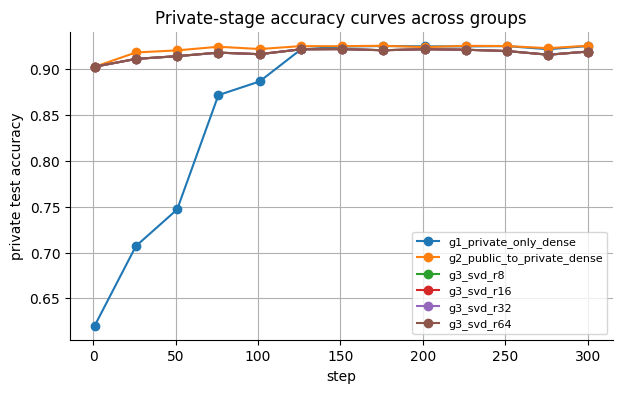

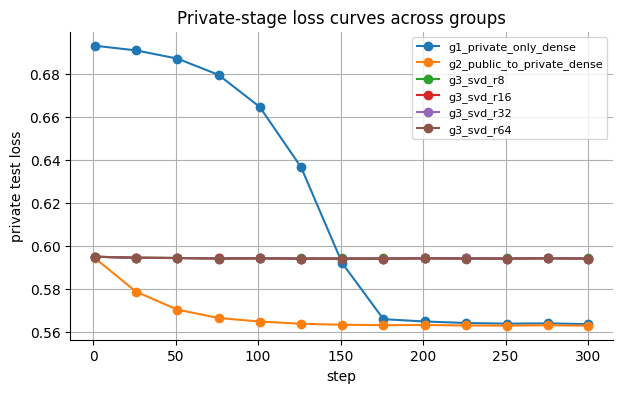

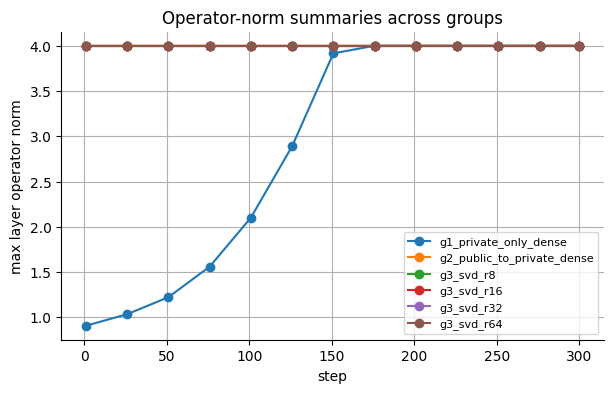

In [77]:
# 1) Overlay private-test accuracy curves
# (diagnostic only; checkpoint_selection='last')

plt.figure(figsize=(7, 4))

for name, bundle in all_bundles.items():
    hist = get_public_curve_history(bundle["release"])
    x, y_curve = extract_curve_xy(hist, "public_eval_accuracy")

    if len(x):
        plt.plot(x, y_curve, marker="o", label=name)

plt.xlabel("step")
plt.ylabel("private test accuracy")
plt.title("Private-stage accuracy curves across groups")
plt.legend(fontsize=8)
plt.show()


# 2) Overlay private-test loss curves

plt.figure(figsize=(7, 4))

for name, bundle in all_bundles.items():
    hist = get_public_curve_history(bundle["release"])
    x, y_curve = extract_curve_xy(hist, "public_eval_loss")

    if len(x):
        plt.plot(x, y_curve, marker="o", label=name)

plt.xlabel("step")
plt.ylabel("private test loss")
plt.title("Private-stage loss curves across groups")
plt.legend(fontsize=8)
plt.show()


# 3) Overlay operator-norm summary curves

plt.figure(figsize=(7, 4))

for name, bundle in all_bundles.items():
    x, y_curve = extract_max_sigma_curve(bundle["release"])

    if len(x):
        plt.plot(x, y_curve, marker="o", label=name)

plt.xlabel("step")
plt.ylabel("max layer operator norm")
plt.title("Operator-norm summaries across groups")
plt.legend(fontsize=8)
plt.show()

## Rank-sweep summary

  

For the SVD group, the most interesting plot is usually:

  

-  **rank vs. private utility**,

-  **rank vs. attack performance**,

- together with the theorem-backed privacy lines.

  

Because the fixed-basis theorem certificate is rank-independent, the privacy lines are expected to be nearly flat.

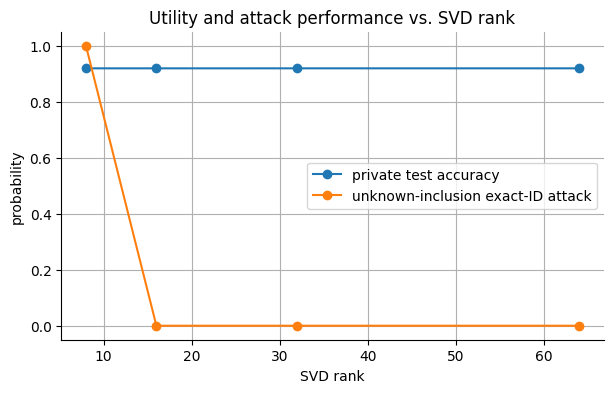

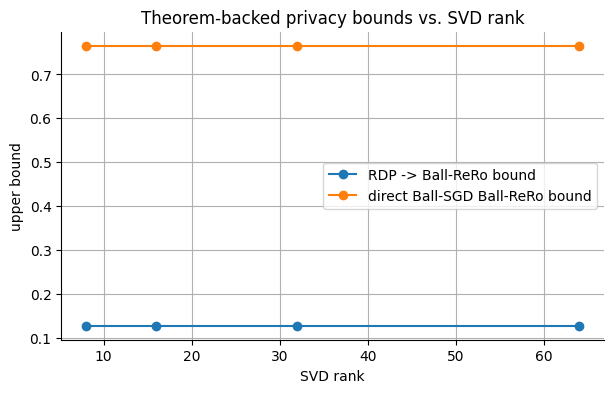

In [81]:
ranks = np.asarray(sorted(svd_bundles.keys()), dtype=np.int32)

acc_rank = np.asarray(
    [
        summarize_bundle(svd_bundles[int(r)])["final_private_test_accuracy"]
        for r in ranks
    ],
    dtype=np.float64,
)

attack_rank = np.asarray(
    [
        summarize_bundle(svd_bundles[int(r)])["attack_unknown_exact_id"]
        for r in ranks
    ],
    dtype=np.float64,
)

rdp_rank = np.asarray(
    [
        summarize_bundle(svd_bundles[int(r)])["gamma_rdp_ball"]
        for r in ranks
    ],
    dtype=np.float64,
)

dir_rank = np.asarray(
    [
        summarize_bundle(svd_bundles[int(r)])["gamma_direct_ball"]
        for r in ranks
    ],
    dtype=np.float64,
)

plt.figure(figsize=(7, 4))
plt.plot(ranks, acc_rank, marker="o", label="private test accuracy")
plt.plot(ranks, attack_rank, marker="o", label="unknown-inclusion exact-ID attack")
plt.xlabel("SVD rank")
plt.ylabel("probability")
plt.title("Utility and attack performance vs. SVD rank")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(ranks, rdp_rank, marker="o", label="RDP -> Ball-ReRo bound")
plt.plot(ranks, dir_rank, marker="o", label="direct Ball-SGD Ball-ReRo bound")
plt.xlabel("SVD rank")
plt.ylabel("upper bound")
plt.title("Theorem-backed privacy bounds vs. SVD rank")
plt.legend()
plt.show()

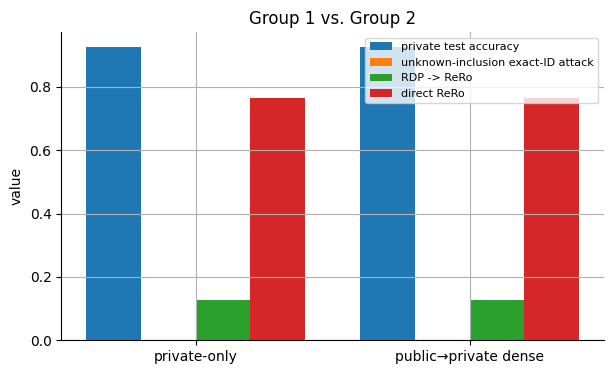

In [79]:
# Compare the three coarse groups by their final private test accuracy and bounds.

coarse_names = [
    "g1_private_only_dense",
    "g2_public_to_private_dense",
]

coarse_labels = ["private-only", "public→private dense"]

coarse_acc = [
    summarize_bundle(all_bundles[k])["final_private_test_accuracy"]
    for k in coarse_names
]

coarse_attack = [
    summarize_bundle(all_bundles[k])["attack_unknown_exact_id"]
    for k in coarse_names
]

coarse_rdp = [
    summarize_bundle(all_bundles[k])["gamma_rdp_ball"]
    for k in coarse_names
]

coarse_dir = [
    summarize_bundle(all_bundles[k])["gamma_direct_ball"]
    for k in coarse_names
]

x = np.arange(len(coarse_labels), dtype=np.float64)
width = 0.2

plt.figure(figsize=(7, 4))
plt.bar(x - 1.5 * width, coarse_acc, width=width, label="private test accuracy")
plt.bar(
    x - 0.5 * width,
    coarse_attack,
    width=width,
    label="unknown-inclusion exact-ID attack",
)
plt.bar(x + 0.5 * width, coarse_rdp, width=width, label="RDP -> ReRo")
plt.bar(x + 1.5 * width, coarse_dir, width=width, label="direct ReRo")
plt.xticks(x, coarse_labels)
plt.ylabel("value")
plt.title("Group 1 vs. Group 2")
plt.legend(fontsize=8)
plt.show()

## What to report from this section

  

For the private-only, public→private dense, and public→private SVD groups, the main quantities are:

  

- final private test accuracy,

- finite-prior unknown-inclusion exact-identification attack,

- optional known-inclusion oracle stress test,

- optimized Ball-RDP $\to$ Ball-ReRo,

- direct Poisson Ball-SGD Ball-ReRo,

- operator-norm curves.

  

For the SVD sweep, the most thesis-relevant picture is often:

  

- a rank-vs-utility curve,

- a rank-vs-attack curve,

- and flat privacy lines showing that rank changes utility / leakage empirically while leaving the theorem certificate unchanged.


In [80]:
# Save a compact JSON summary for later aggregation across datasets.

summary = {
    "radius_priv": float(radius_priv),
    "B_all": float(B_all),
    "dense_lz": float(lz_dense),
    "clip_norm": float(clip_norm),
    "noise_multiplier": float(noise_multiplier),
    "m_candidates": int(m_candidates),
    "group_summaries": summary_rows,
    "svd_ranks": [int(r) for r in ranks.tolist()],
    "svd_rank_accuracy": acc_rank.tolist(),
    "svd_rank_attack_unknown_exact_id": attack_rank.tolist(),
    "svd_rank_rdp_bound": rdp_rank.tolist(),
    "svd_rank_direct_bound": dir_rank.tolist(),
}

summary_path = THEOREM_RESULTS_DIR / "theorem_svd_demo_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("saved summary to:", summary_path)
summary

saved summary to: results_ball_dp_theorem_svd_demo/theorem_svd_demo_summary.json


{'radius_priv': 0.1,
 'B_all': 1.0000001192092896,
 'dense_lz': 2.2365264409661334,
 'clip_norm': 0.25,
 'noise_multiplier': 0.7342529296875,
 'm_candidates': 16,
 'group_summaries': [{'name': 'group1_private_only_dense',
   'final_private_test_accuracy': 0.92528,
   'attack_unknown_exact_id': 0.0,
   'gamma_rdp_ball': 0.12727579297346578,
   'gamma_rdp_standard': 1.0,
   'alpha_opt_ball': 5.0,
   'gamma_direct_ball': 0.7653838582887923,
   'gamma_direct_standard': 1.0},
  {'name': 'group2_public_to_private_dense',
   'final_private_test_accuracy': 0.9256,
   'attack_unknown_exact_id': 0.0,
   'gamma_rdp_ball': 0.12727579297346578,
   'gamma_rdp_standard': 1.0,
   'alpha_opt_ball': 5.0,
   'gamma_direct_ball': 0.7653838582887923,
   'gamma_direct_standard': 1.0},
  {'name': 'group3_public_to_private_svd_rank_8',
   'final_private_test_accuracy': 0.91924,
   'attack_unknown_exact_id': 1.0,
   'gamma_rdp_ball': 0.12727579297346578,
   'gamma_rdp_standard': 1.0,
   'alpha_opt_ball': 5.0,
